# 🛢️ Volve Field — ML Water Cut Prediction

Epsilon AI Academy | Graduation Project


## Project Objective

Build a machine learning model that predicts next month's water cut (%) per well — turning historical production data into a monthly early-warning system for water management decisions.

## Pipeline Summary

| Phase | Description |
|---|---|
| EDA | Production trends, well comparison, water breakthrough analysis |
| Feature Engineering | Lag features, GOR, well age, cumulative oil, well identity encoding |
| Modelling | Linear Regression · Random Forest · Gradient Boosting via GridSearchCV + TimeSeriesSplit |
| Evaluation | RMSE, MAE, R² on held-out test set (80th percentile time cutoff) |
| Deployment | Streamlit multi-page dashboard with Live Prediction page |

# Discover the dataset

### About the dataset
In June 2018, the Norwegian Oil & Gas company **Equinor** announced that they would be sharing a complete set of data from the Norwegian continental shelf for research and study purposes, thus granting all academic institutions, students, and researchers permission to use this dataset in accordance with the [Equinor Open Data Licence](https://cdn.equinor.com/files/h61q9gi9/global/de6532f6134b9a953f6c41bac47a0c055a3712d3.pdf?equinor-hrs-terms-and-conditions-for-licence-to-data-volve.pdf), without any need for further written permission.

The Volve production data was released in the form of an excel file made up of two (02) sheets, namely **Daily Production Data** and **Monthly Production Data**.

## Key points about the industry

### Definitions

**Wellbore**: is a hole that is drilled to aid in the exploration and recovery of natural resources, including oil, gas, or water.

**Hydrocarbons**: is a term generally used to designate oil and gas.

### Important notes

In the Oil & Gas industry, when a wellbore starts producing hydrocarbons, the amount of pressure required to move the hydrocarbons from the reservoir to the surface is provided by natural forces, also known as [natural drive mechanisms](https://wiki.aapg.org/Reservoir_drive_mechanisms).

However, these forces get depleted with time and become insufficient to drive the hydrocarbons to the surface. To tackle this problem, [secondary recovery methods](https://www.britannica.com/technology/petroleum-production/Recovery-of-oil-and-gas#ref623983) were introduced, which consist of injecting water or gas to displace the hydrocarbons and drive them through a production wellbore to the surface.

In [937]:
import pandas as pd

In [938]:
volve_df = pd.read_excel(io="Volve production data.xlsx", sheet_name="Monthly Production Data")

In [939]:
volve_df

,Wellbore name,NPDCode,Year,Month,On Stream,Oil,Gas,Water,GI,WI
0,NaN,NaN,NaN,NaN,hrs,Sm3,Sm3,Sm3,Sm3,Sm3
1,15/9-F-1 C,7405.0,2014.0,4.0,227.5,11142.47,1597936.65,0,NaN,NaN
2,15/9-F-1 C,7405.0,2014.0,5.0,733.83334,24901.95,3496229.65,783.48,NaN,NaN
3,15/9-F-1 C,7405.0,2014.0,6.0,705.91666,19617.76,2886661.69,2068.48,NaN,NaN
4,15/9-F-1 C,7405.0,2014.0,7.0,742.41666,15085.68,2249365.75,6243.98,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
522,15/9-F-5,5769.0,2016.0,5.0,732,9724.4,1534677.16,3949.9,NaN,0
523,15/9-F-5,5769.0,2016.0,6.0,718.41667,9121.48,1468557.12,2376.93,NaN,NaN
524,15/9-F-5,5769.0,2016.0,7.0,668.64168,9985.29,1602674.39,2453.71,NaN,0
525,15/9-F-5,5769.0,2016.0,8.0,608.425,8928.9,1417278.51,2371.86,NaN,0


## Questions and Answers

### What is the dataset about?

- The dataset provides hydrocarbon production data from the Volve field in Norway.

### What does each column tell us about?

|Column        | Information                                           | Unit        |
|:-------------|:-----------------------------------------------------:|------------:|
|Wellbore name | The name of the wellbore                              | NA          |
|NPDCode       | Norwegian Petroleum Directorate Code                  | NA          |
|Year          | The year of record                                    | NA          |
|Month         | The month of record                                   | NA          |
|On Stream     | The duration of a wellbore in operation               | hours       |
|Oil           | The Volume of oil produced                            | cubic meters|
|Gas           | The Volume of gas produced                            | cubic meters|
|Water         | The Volume of water produced                          | cubic meters|
|GI            | The Volume of gas injected during secondary recovery  | cubic meters|
|WI            | The Volume of water injected during secondary recovery| cubic meters|

In [940]:
volve_df.dtypes

Wellbore name        str
NPDCode          float64
Year             float64
Month            float64
On Stream         object
Oil               object
Gas               object
Water             object
GI                   str
WI                object
dtype: object

## Questions and Answers

### Which of the available columns are correctly formatted?
- The column `Wellbore name` is the only one in a correct format.

### Which of the available columns require type conversion?
- `NPDCode`, `Year`, `Month`: float ->  int
- `On Stream`, `Oil`, `Gas`, `Water`, `GI`, `WI`: object -> float

Let's try to transform our data columns into appropriate data types.

In [941]:
volve_df = volve_df.drop(index=[0]).reset_index(drop=True)

In [942]:
volve_df[["NPDCode", "Year", "Month"]] = volve_df[["NPDCode", "Year", "Month"]].astype(int)
volve_df[["On Stream", "Oil", "Gas", "Water", "WI", "GI"]] = volve_df[["On Stream", "Oil", "Gas", "Water", "WI", "GI"]].astype(float)

In [943]:
volve_df.dtypes

Wellbore name        str
NPDCode            int64
Year               int64
Month              int64
On Stream        float64
Oil              float64
Gas              float64
Water            float64
GI               float64
WI               float64
dtype: object

## Questions and Answers

### Questions

- Which of the available columns contain missing values?
- How do you intend to handle the missing values?

In [944]:
volve_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 526 entries, 0 to 525
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Wellbore name  526 non-null    str    
 1   NPDCode        526 non-null    int64  
 2   Year           526 non-null    int64  
 3   Month          526 non-null    int64  
 4   On Stream      515 non-null    float64
 5   Oil            311 non-null    float64
 6   Gas            311 non-null    float64
 7   Water          311 non-null    float64
 8   GI             0 non-null      float64
 9   WI             201 non-null    float64
dtypes: float64(6), int64(3), str(1)
memory usage: 45.8 KB


In [945]:
volve_df.describe()

,NPDCode,Year,Month,On Stream,Oil,Gas,Water,GI,WI
count,526.000000,526.000000,526.000000,515.000000,311.000000,3.110000e+02,311.000000,0.0,201.000000
mean,5906.731939,2012.380228,6.482890,595.901633,32273.571093,4.743956e+06,49255.878939,NaN,150896.186722
std,650.021100,2.633829,3.417977,196.676640,37361.937092,5.302562e+06,47458.158698,NaN,56431.406213
min,5351.000000,2007.000000,1.000000,0.000000,0.000000,0.000000e+00,0.000000,NaN,0.000000
25%,5599.000000,2010.000000,4.000000,561.334160,6085.665000,9.236522e+05,3534.335000,NaN,126376.884487
50%,5693.000000,2013.000000,6.500000,683.741660,17870.720000,2.722573e+06,36195.930000,NaN,150430.986280
75%,5769.000000,2015.000000,9.000000,720.000000,37607.385000,5.780980e+06,94056.455000,NaN,188426.124913
max,7405.000000,2016.000000,12.000000,745.000000,166439.670000,2.410636e+07,155365.680000,NaN,270199.399830


### Answers

- The columns `On Stream`, `Oil`, `Gas`, `Water`, `GI`, and `WI` all contain missing values.
- Given the high standard deviation for the concerned columns (*cell above*), the best option is to replace them with zero (0).

>**Note:** The standard deviation is considered high when it is more than one third of the arithmetic mean.

In [946]:
volve_df = volve_df.fillna(0)

In [947]:
volve_df.head(10)

,Wellbore name,NPDCode,Year,Month,On Stream,Oil,Gas,Water,GI,WI
0,15/9-F-1 C,7405,2014,4,227.50000,11142.47,1597936.65,0.00,0.0,0.0
1,15/9-F-1 C,7405,2014,5,733.83334,24901.95,3496229.65,783.48,0.0,0.0
2,15/9-F-1 C,7405,2014,6,705.91666,19617.76,2886661.69,2068.48,0.0,0.0
3,15/9-F-1 C,7405,2014,7,742.41666,15085.68,2249365.75,6243.98,0.0,0.0
4,15/9-F-1 C,7405,2014,8,432.99166,6970.43,1048190.80,4529.75,0.0,0.0
5,15/9-F-1 C,7405,2014,9,630.30000,9168.43,1414099.99,8317.59,0.0,0.0
6,15/9-F-1 C,7405,2014,10,745.00000,9468.06,1462063.99,10364.87,0.0,0.0
7,15/9-F-1 C,7405,2014,11,579.77500,6710.33,1044188.30,7234.24,0.0,0.0
8,15/9-F-1 C,7405,2014,12,27.50000,120.29,25857.08,183.44,0.0,0.0
9,15/9-F-1 C,7405,2015,1,479.91667,10875.53,1604934.60,6850.80,0.0,0.0


## Questions and Answers

### Questions

- What is the temporal coverage of the dataset?
- How many wellbores are there in the dataset?
- How much hydrocarbon was produced from the Volve field?
- What secondary recovery method was employed during field development?

In [948]:
years = sorted(list(volve_df["Year"].unique()))
temporal_coverage = years[-1] - years[0]

print(f"The dataset provides production data for a duration of {temporal_coverage} years, from {years[0]} to {years[-1]}.")

The dataset provides production data for a duration of 9 years, from 2007 to 2016.


In [949]:
number_of_wells = len(volve_df["Wellbore name"].unique())
print(f"There is a total of {number_of_wells} wellbores in the dataset.")

There is a total of 7 wellbores in the dataset.


### Unit convension

- Oil reserves are measured in barrels (bbl)
- Gas reserves are measured in standard cubic feet (SCF or ft<sup>3</sup>)

>1 bbl = 0.1589873 m<sup>3</sup> <br>
>1 scf = 0.0283168 m<sup>3</sup>

In [950]:
total_oil_production = volve_df["Oil"].sum() / 0.1589873
total_gas_production = volve_df["Gas"].sum() / 0.0283168

In [951]:
print("A total of {:.2f} million barrels of oil were produced.".format(total_oil_production / 1e6))

A total of 63.13 million barrels of oil were produced.


In [952]:
print("A total of {:.2f} billion cubic feet of gas were produced.".format(total_gas_production / 1e9))

A total of 52.10 billion cubic feet of gas were produced.


In [953]:
if volve_df["WI"].sum() > 0:
    if volve_df["GI"].sum() > 0:
        print("Both gas and water injection were used for the secondary recovery.")
    else:
        print("Water injection was used as the secondary recovery method.")
else:
    print("Gas injection was used as the secondary recovery method.")

Water injection was used as the secondary recovery method.


### Basic Information

|Field name | Location | No of wells | Temporal coverage      |
|:---------:|:--------:|:-----------:|:----------------------:|
|Volve      |Norway    |7            |9 years (_2007 - 2016_) |

### Performance Evaluation

| Oil Production | Gas Production | Recovery Method |
|:--------------:|:--------------:|:---------------:|
| 62.73 MMbbl    | 52.10 BCF      |Water injection  |

## Data Cleaning

To clean the dataset, we will proceed the following way:

- Format column names to `SCREAMING_SNAKE_CASE`
- Drop the first row
- Replace missing values with zero
- Make the necessary type conversions
- Change the `Month` column into month abbreviations (*1 -> Jan, 2 -> Feb, ...etc*)
- Create a function to automate the process

This Section covers the following topics:

- [Data Cleaning](#data-cleaning)
- [Data Transformation](#data-transformation)
  - [Sorting](#sorting)
  - [Query and Aggregation](#query-and-aggregation)
    - [Annual Dataframes](#annual-dataframes)
    - [Monthly Dataframes](#monthly-dataframes)
- [Questions and Answers](#questions-and-answers)
- [Bonus: Automate dataframes generation](#bonus:-automate-dataframes-generation)
- [Tests](#tests)

In [954]:
from typing import Dict, Literal, Optional
import calendar
import pandas as pd

In [955]:
volve_df.columns = volve_df.columns.str.replace(" ", "_")
volve_df.columns = volve_df.columns.str.upper()

In [956]:
volve_df = volve_df.drop(index=[0]).reset_index(drop=True)

In [957]:
volve_df = volve_df.fillna(0)

In [958]:
volve_df[["NPDCODE", "YEAR", "MONTH"]] = volve_df[["NPDCODE", "YEAR", "MONTH"]].astype(int)
volve_df[["ON_STREAM", "OIL", "GAS", "WATER", "WI", "GI"]] = volve_df[["ON_STREAM", "OIL", "GAS", "WATER", "WI", "GI"]].astype(float)

In [959]:
abbreviations = dict(enumerate(calendar.month_abbr))
abbreviations

{0: '',
 1: 'Jan',
 2: 'Feb',
 3: 'Mar',
 4: 'Apr',
 5: 'May',
 6: 'Jun',
 7: 'Jul',
 8: 'Aug',
 9: 'Sep',
 10: 'Oct',
 11: 'Nov',
 12: 'Dec'}

In [960]:
abbreviations.pop(0)

''

In [961]:
volve_df["MONTH"] = volve_df["MONTH"].map(abbreviations)
volve_df["MONTH"] = pd.Categorical(volve_df["MONTH"], categories=list(abbreviations.values()), ordered=True)

In [962]:
def clean_data(data: pd.DataFrame) -> pd.DataFrame:
    df = data.copy()

    # Format column names to SCREAMING_SNAKE_CASE
    df.columns = df.columns.str.replace(" ", "_")
    df.columns = df.columns.str.upper()

    # To avoid confusion in case of a csv file
    df = df.replace(",", "", regex=True)

    df = df.drop(index=[0]).reset_index(drop=True)
    df = df.fillna(0)

    df[["NPDCODE", "YEAR", "MONTH"]] = df[["NPDCODE", "YEAR", "MONTH"]].astype(int)
    df[["ON_STREAM", "OIL", "GAS", "WATER", "WI", "GI"]] = df[["ON_STREAM", "OIL", "GAS", "WATER", "WI", "GI"]].astype(float)

    # Convert months to month abbreviations, 1 -> Jan, 2 -> Feb, ...etc
    abbr = dict(enumerate(calendar.month_abbr))
    abbr.pop(0)
    df["MONTH"] = df["MONTH"].map(abbr)
    df["MONTH"] = pd.Categorical(df["MONTH"], categories=list(abbr.values()), ordered=True)

    return df

In [963]:
volve_df.head(10)

,WELLBORE_NAME,NPDCODE,YEAR,MONTH,ON_STREAM,OIL,GAS,WATER,GI,WI
0,15/9-F-1 C,7405,2014,May,733.83334,24901.95,3496229.65,783.48,0.0,0.0
1,15/9-F-1 C,7405,2014,Jun,705.91666,19617.76,2886661.69,2068.48,0.0,0.0
2,15/9-F-1 C,7405,2014,Jul,742.41666,15085.68,2249365.75,6243.98,0.0,0.0
3,15/9-F-1 C,7405,2014,Aug,432.99166,6970.43,1048190.80,4529.75,0.0,0.0
4,15/9-F-1 C,7405,2014,Sep,630.30000,9168.43,1414099.99,8317.59,0.0,0.0
5,15/9-F-1 C,7405,2014,Oct,745.00000,9468.06,1462063.99,10364.87,0.0,0.0
6,15/9-F-1 C,7405,2014,Nov,579.77500,6710.33,1044188.30,7234.24,0.0,0.0
7,15/9-F-1 C,7405,2014,Dec,27.50000,120.29,25857.08,183.44,0.0,0.0
8,15/9-F-1 C,7405,2015,Jan,479.91667,10875.53,1604934.60,6850.80,0.0,0.0
9,15/9-F-1 C,7405,2015,Feb,437.41667,9586.64,1439453.67,10744.99,0.0,0.0


## Data Transformation

The previous notebook revealed that the dataset has a temporal coverage of 9 years, going from **2007** to **2016**. However, the above cell shows the dataset starting from **2014**. This is because information were entered in the order `WELLBORE_NAME -> YEAR -> MONTH`.

To have the dataset to appear in a chronological order, we can always sort it by `YEAR` then by `MONTH`.

**Note:** This won't be necessary for the rest of the analysis, but I had to mention it.

In [964]:
volve_df = volve_df.sort_values(["YEAR", "MONTH"]).reset_index(drop=True)

In [965]:
volve_df

,WELLBORE_NAME,NPDCODE,YEAR,MONTH,ON_STREAM,OIL,GAS,WATER,GI,WI
0,15/9-F-4,5693,2007,Sep,0.00000,0.0,0.0,0.0,0.0,0.000000
1,15/9-F-5,5769,2007,Sep,0.00000,0.0,0.0,0.0,0.0,0.000000
2,15/9-F-4,5693,2007,Oct,0.00000,0.0,0.0,0.0,0.0,0.000000
3,15/9-F-5,5769,2007,Oct,0.00000,0.0,0.0,0.0,0.0,0.000000
4,15/9-F-4,5693,2007,Nov,0.00000,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...
520,15/9-F-4,5693,2016,Sep,340.10833,0.0,0.0,0.0,0.0,61200.875995
521,15/9-F-5,5769,2016,Sep,0.00000,0.0,0.0,0.0,0.0,0.000000
522,15/9-F-4,5693,2016,Oct,0.00000,0.0,0.0,0.0,0.0,0.000000
523,15/9-F-4,5693,2016,Nov,0.00000,0.0,0.0,0.0,0.0,0.000000


### Query and Aggregation

Now that the dataset is clean and sorted, creating smaller reusable chunks from it will help ensure a more targeted analysis.

To do so, we will proceed the following way:

- Create annual dataframes
- Add columns to account for the cummulated production
- Create monthly dataframes
- Create functions to automate the processes

#### Annual dataframes

In [966]:
def get_annual_data(data: pd.DataFrame, category: Optional[Literal["production", "injection"]] = None) -> pd.DataFrame:

    df = data.groupby("YEAR", as_index=False)[["ON_STREAM", "OIL", "GAS", "WATER", "WI", "GI"]].sum()

    if not category:
        return df

    category = category.strip().lower()

    if category in ["production", "prod"]:
        df["CUM_OIL"] = df["OIL"].cumsum()
        df["CUM_GAS"] = df["GAS"].cumsum()
        df["CUM_WATER"] = df["WATER"].cumsum()
        df = df.drop(columns=["ON_STREAM", "GI", "WI"])

    elif category in ["injection", "inj"]:
        df = df[["YEAR", "GI", "WI"]]

    return df

In [967]:
get_annual_data(data=volve_df)

,YEAR,ON_STREAM,OIL,GAS,WATER,WI,GI
0,2007,0.00000,0.00,0.000000e+00,0.00,0.000000e+00,0.0
1,2008,19064.34621,1764375.15,2.570386e+08,23508.94,2.417770e+06,0.0
2,2009,30888.38339,2684392.04,3.759820e+08,232103.74,4.392198e+06,0.0
3,2010,31982.45835,1689902.55,2.439484e+08,1887594.78,4.569394e+06,0.0
4,2011,26965.34005,847965.40,1.303202e+08,2190640.28,3.442446e+06,0.0
5,2012,28220.15000,574206.33,9.020864e+07,2109601.63,2.975214e+06,0.0
6,2013,33686.14435,558012.53,8.758778e+07,2576365.79,3.453761e+06,0.0
7,2014,50333.53695,731965.02,1.101939e+08,2716070.92,3.825493e+06,0.0
8,2015,53352.33783,861749.06,1.284238e+08,2009825.86,3.201627e+06,0.0
9,2016,32169.14366,313370.06,5.006913e+07,1572866.41,2.052229e+06,0.0


#### Monthly dataframes

In [968]:
def get_monthly_data(
    data: pd.DataFrame,
    parameter: Optional[Literal["ON_STREAM", "OIL", "GAS", "WATER", "GI", "WI"]] = None
) -> pd.DataFrame:

    df = data.groupby(["YEAR", "MONTH"], as_index=False)[["ON_STREAM", "OIL", "GAS", "WATER", "GI", "WI"]].sum()

    if not parameter:
        return df

    parameter = parameter.strip().upper().replace(" ", "_")
    df = df.pivot_table(values=parameter, index="MONTH", columns="YEAR")

    return df

In [969]:
get_monthly_data(data=volve_df)

,YEAR,MONTH,ON_STREAM,OIL,GAS,WATER,GI,WI
0,2007,Sep,0.00000,0.00,0.00,0.00,0.0,0.000000
1,2007,Oct,0.00000,0.00,0.00,0.00,0.0,0.000000
2,2007,Nov,0.00000,0.00,0.00,0.00,0.0,0.000000
3,2007,Dec,0.00000,0.00,0.00,0.00,0.0,0.000000
4,2008,Jan,0.00000,0.00,0.00,0.00,0.0,0.000000
...,...,...,...,...,...,...,...,...
107,2016,Aug,2294.56667,24954.66,3991207.77,101071.19,0.0,132382.877395
108,2016,Sep,732.38347,8609.18,1458816.35,46779.39,0.0,61200.875995
109,2016,Oct,0.00000,0.00,0.00,0.00,0.0,0.000000
110,2016,Nov,0.00000,0.00,0.00,0.00,0.0,0.000000


uestions and Answers

### Questions

- How many production wellbores are there in the dataset?
- How many injection wellbores are there in the dataset?

To answer these questions, let's create another data segment to store the computed yield of each wellbore.

In [970]:
def wellbores_data(data: pd.DataFrame, category: Optional[Literal["production", "injection", "hybrid"]] = None) -> pd.DataFrame:

    df = data.groupby("WELLBORE_NAME", as_index=False)[["ON_STREAM", "OIL", "GAS", "WATER", "GI", "WI"]].sum()

    if not category:
        return df

    category = category.strip().lower()

    if category in ["production", "prod"]:
        df = df.query("OIL > 0 or GAS > 0")
    elif category in ["injection", "inj"]:
        df = df.query("GI > 0 or WI > 0")
    elif category in ["hybrid", "hb"]:
        df = df.query("(OIL > 0 or GAS > 0) and (GI > 0 or WI > 0)")

    df = df.reset_index(drop=True)

    return df

In [971]:
wellbores_data(data=volve_df,category='production')

,WELLBORE_NAME,ON_STREAM,OIL,GAS,WATER,GI,WI
0,15/9-F-1 C,9756.03315,166566.86,2.484298e+07,207302.39,0.0,0.000000e+00
1,15/9-F-11,26006.21614,1147849.10,1.743105e+08,1090806.27,0.0,0.000000e+00
2,15/9-F-12,65204.06928,4579609.55,6.675423e+08,6833320.37,0.0,0.000000e+00
3,15/9-F-14,62773.67519,3942233.39,5.780095e+08,7121249.74,0.0,0.000000e+00
4,15/9-F-15 D,17824.83278,148518.56,2.250535e+07,52366.40,0.0,0.000000e+00
5,15/9-F-5,60829.85308,41160.68,6.561826e+06,13533.18,0.0,1.408941e+07


In [972]:
wellbores_data(data=volve_df,category='injection')

,WELLBORE_NAME,ON_STREAM,OIL,GAS,WATER,GI,WI
0,15/9-F-4,64267.16117,0.00,0.00,0.00,0.0,1.624073e+07
1,15/9-F-5,60829.85308,41160.68,6561825.74,13533.18,0.0,1.408941e+07


In [973]:
wellbores_data(data=volve_df,category='hybrid')

,WELLBORE_NAME,ON_STREAM,OIL,GAS,WATER,GI,WI
0,15/9-F-5,60829.85308,41160.68,6561825.74,13533.18,0.0,1.408941e+07


### Answers

Out of the seven (07) wellbores:
- Six (06) were used for hydrocarbon production
- Two (02) were used for water injection during secondary recovery

However, `6+2=8` and the dataset only shows seven (07) wellbores. This implies that one of the wellbores was used for both hydrocarbon production and water injection.

Let's find out which wellbore it is.

Knowing that the wellbore `15/9-F-5` was used for both hydrocarbon production and water injection, it would be legitimate to ask ourselves the following questions:

### Questions

- How long has the wellbore been used for hydrocarbon production?
- How long has it been used for water injection?

Moreover, in oil and gas production operations, not all wellbores are drilled early in the field's life. New wellbores may be drilled after the beginning of operations to increase production, and some may be shut down due to severe technical issues or to decrease production rates for economic reasons. Therefore, obtaining historical data for each wellbore can help provide a more accurate picture of events.

It is thus necessary to create individual subsets for each of the wellbores. As there are seven (07) wellbores in the dataset, creating subsets one by one would be tedious. Instead, let's create functions to automate the process.

In [974]:
def get_well_data(data: pd.DataFrame, well_name: str) -> pd.DataFrame:

    well_name = well_name.strip().upper()
    df = data.query("`WELLBORE_NAME` == @well_name").reset_index(drop=True)

    return df

In [975]:
def get_well_annual_data(
    data: pd.DataFrame,
    well_name: str,
    category: Optional[Literal["production", "injection"]] = None
) -> pd.DataFrame:

    df = get_well_data(data=data, well_name=well_name)
    df = df.groupby("YEAR", as_index=False)[["ON_STREAM", "OIL", "GAS", "WATER", "GI", "WI"]].sum()

    if not category:
        return df

    category = category.strip().lower()
    if category in ["production", "prod"]:
        df["CUM_OIL"] = df["OIL"].cumsum()
        df["CUM_GAS"] = df["GAS"].cumsum()
        df["CUM_WATER"] = df["WATER"].cumsum()
        df = df.drop(columns=["ON_STREAM", "GI", "WI"])

    elif category in ["injection", "inj"]:
        df = df[["YEAR", "GI", "WI"]]

    return df

In [976]:
# Note: If the argument 'parameter' is not provided,
# the returned dataframe will be the same as the was obtained from the function 'well_data'

def get_well_monthly_data(
    data: pd.DataFrame,
    well_name: str,
    parameter: Optional[Literal["ON_STREAM", "OIL", "GAS", "WATER", "GI", "WI"]] = None
) -> pd.DataFrame:
    df = get_well_data(data=data, well_name=well_name)

    if not parameter:
        return df

    parameter = parameter.strip().upper().replace(" ", "_")
    df = df.pivot_table(values=parameter, index="MONTH", columns="YEAR", fill_value=0)

    return df

In [977]:
get_well_annual_data(data=volve_df, well_name="15/9-f-5")

,YEAR,ON_STREAM,OIL,GAS,WATER,GI,WI
0,2007,0.00000,0.00,0.00,0.00,0.0,0.000000e+00
1,2008,2678.37890,0.00,0.00,0.00,0.0,6.915290e+05
2,2009,7560.94328,0.00,0.00,0.00,0.0,2.242719e+06
3,2010,7852.04170,0.00,0.00,0.00,0.0,2.303923e+06
4,2011,6722.10837,0.00,0.00,0.00,0.0,1.721295e+06
5,2012,7057.86667,0.00,0.00,0.00,0.0,1.514296e+06
6,2013,7583.03501,0.00,0.00,0.00,0.0,1.788601e+06
7,2014,7783.07965,0.00,0.00,0.00,0.0,1.785109e+06
8,2015,8363.83279,0.00,0.00,0.00,0.0,1.569313e+06
9,2016,5228.56671,41160.68,6561825.74,13533.18,0.0,4.726207e+05


In [978]:
get_well_monthly_data(data=volve_df, well_name="15/9-f-5", parameter="wi")

YEAR,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
MONTH,,,,,,,,,,
Jan,0.0,0.000000,253655.425801,251554.767873,189041.119519,96145.249734,159939.686389,139161.964208,116851.662330,148394.556100
Feb,0.0,0.000000,226102.013160,199239.179513,139466.556430,144177.133349,147798.464818,139875.109217,122957.754830,164188.597139
Mar,0.0,0.000000,81674.350000,159955.292047,184592.187691,144901.311794,85998.065149,168354.400345,127803.687133,139810.591271
Apr,0.0,0.000000,104818.547780,143182.227376,188899.232610,152913.710861,121656.595674,170365.945108,146997.138336,20226.958790
May,0.0,0.000000,232334.514448,252211.737628,191438.083542,157759.447593,170935.465968,155443.530098,135253.884264,0.000000
Jun,0.0,0.000000,133204.205271,217995.582733,115810.712320,147174.916348,138629.205472,170548.081449,146025.800913,0.000000
Jul,0.0,0.000000,205447.018688,213816.939548,60234.670729,155141.689089,131248.921444,149633.537327,117659.770350,0.000000
Aug,0.0,14480.932077,198473.659979,120306.477756,161568.571770,65973.970819,185791.651601,122109.851845,113141.006224,0.000000
Sep,0.0,64814.286524,171773.204863,163185.260243,185636.237526,8067.451343,141322.974441,160662.468334,128260.871127,0.000000


In [979]:
get_well_monthly_data(data=volve_df, well_name="15/9-f-5", parameter="oil")

YEAR,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
MONTH,,,,,,,,,,
Jan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
Feb,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
Mar,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
Apr,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3400.61
May,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9724.40
Jun,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9121.48
Jul,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9985.29
Aug,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8928.90
Sep,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00


### Answers

The wellbore `15/9-F-5` was primarily used as an injection wellbore, from `August 2008` to `April 2016`, before being converted into a production wellbore until `August 2016`.

In [980]:
def determine_well_type(data: pd.DataFrame, well_name: str) -> str:
     well_df = get_well_data(data, well_name)

     if sum(well_df["OIL"] + well_df["GAS"]) > 0:
          if sum(well_df["GI"] + well_df["WI"]) > 0:
               return "HYBRID"
          else:
               return "PRODUCTION"
     else:
          return "INJECTION"

In [981]:
def wellbores_details(data: pd.DataFrame) -> pd.DataFrame:
    details_dict = {
        "WELLBORE_NAME": [],
        "WELLBORE_TYPE": [],
        "FIRST_RECORD": [],
        "LAST_RECORD": [],
    }

    for wellbore in data["WELLBORE_NAME"].unique():
        well_df = get_well_data(data, wellbore)
        details_dict["WELLBORE_NAME"].append(wellbore)
        details_dict["WELLBORE_TYPE"].append(determine_well_type(data, wellbore))
        details_dict["FIRST_RECORD"].append(well_df["YEAR"].min())
        details_dict["LAST_RECORD"].append(well_df["YEAR"].max())

    return pd.DataFrame(details_dict).sort_values("FIRST_RECORD").reset_index(drop=True)

In [982]:
wellbores_details(volve_df)

,WELLBORE_NAME,WELLBORE_TYPE,FIRST_RECORD,LAST_RECORD
0,15/9-F-4,INJECTION,2007,2016
1,15/9-F-5,HYBRID,2007,2016
2,15/9-F-12,PRODUCTION,2008,2016
3,15/9-F-14,PRODUCTION,2008,2016
4,15/9-F-11,PRODUCTION,2013,2016
5,15/9-F-15 D,PRODUCTION,2014,2016
6,15/9-F-1 C,PRODUCTION,2014,2016


### Observations

The above dataframe reveals that out of seven (07) wellbores:
- Four (04) started operating at the beginning of the field's life (*2007 - 2008*)
- Three (03) were drilled years later, probably to increase the production
- All wellbores stopped operating in **2016**

**Note:** The graphical analysis of the annual production in the next notebook may reveal an increase in production around **2014**.

### Question

- What could have motivated the company to increase the production?

### Answer

>#### Oil market chronology
>
>- According to the [U.S. Energy Information Administration](https://www.eia.gov/todayinenergy/detail.php?id=7630#:~:text=Crude%20oil%20prices%20rose%20during,start%20of%20the%20third%20quarter.), &ldquo;<cite>Crude oil prices rose during the first quarter of 2012 as concerns about possible international supply disruptions pushed up petroleum prices. Prices then fell during the second quarter before turning sharply upward at the start of the third quarter.</cite>&rdquo;
>
>- In **2013**, Brent crude rose above &dollar;110 and the [International Energy Agency](https://en.wikipedia.org/wiki/International_Energy_Agency) said demand for oil would still rise. <cite>(Source: [Wikipedia](https://en.wikipedia.org/wiki/2011%E2%80%932013_world_oil_market_chronology#:~:text=Oil%20supplies%20remained%20high%2C%20and,years%2C%20with%20gasoline%20prices%20following.))</cite>
>
><br>
>
>#### Annual Reports
>
>The [2013 Annual Report](https://cdn.equinor.com/files/h61q9gi9/global/f7148331f9bfa5ddb7b7b9851bc94e9bff66dfb0.pdf?statoil-annual-report-20-F-2013.pdf) from **Equinor/Statoil** states that:
>- &ldquo;<cite>Volve has executed a drilling programme in 2013. The drilling of well F11-A, and a successful exploration pilot at Volve North West, have increased the proved reserves. As a result the field life has been extended by two years, and production is now expected to run to the third quarter of 2016.</cite>&rdquo; (page 20)
>
><br>
>
>Moreover, the [2014 Annual Report](https://cdn.equinor.com/files/h61q9gi9/global/b2c0248e609fa8783137514d8fd0ca09f9a1ec5e.pdf?Statoil-20-F-2014.pdf) states that:
>- **Page 9**: &ldquo;<cite>After more than three years of relatively stable prices, 2014 saw the price of Brent crude climb to USD 115 per barrel in June before dropping to USD 55 per barrel at the end of December.</cite>&rdquo; <br><br>
>- **Page 23**: &ldquo;<cite>Volve (Statoil interest 59.60%) has successfully increased the proven reserve via a drilling program in 2014.</cite>&rdquo; <br><br>

#### Conclusion

With the regular rise of oil prices from **2012** and larger hydrocarbon reserves, the company may have decided to increase production to maximize its profits. The Annual Reports also confirm our understanding of the chronology of events during field development.

## Bonus: Automate dataframes generation

When graphically analyzing the dataset in the next notebook, it will be essential to generate numerous subsets to account for various data classifications. This could result in writing multiple lines to generate dataframes of the same scope (*annual for example*). It would thus be time-saving to have a function capable of generating all these, allowing us to access multiple dataframes in a single line through [unpacking](https://www.w3schools.com/python/python_tuples_unpack.asp).

In [983]:
def annual_data(
    data: pd.DataFrame,
    well_name: Optional[str] = None,
    category: Optional[Literal["production", "injection"]] = None
) -> pd.DataFrame:
    if well_name:
        return get_well_annual_data(data, well_name, category)
    else:
        return get_annual_data(data, category)

In [984]:
def monthly_data(
    data: pd.DataFrame,
    well_name: Optional[str] = None,
    parameter: Optional[Literal["ON_STREAM", "OIL", "GAS", "WATER", "GI", "WI"]] = None
) -> pd.DataFrame:
    if well_name:
        return get_well_monthly_data(data, well_name, parameter)
    else:
        return get_monthly_data(data, parameter)

⚠️`WARNING!:` Python dictionaries are case sensitive. Be careful when using the [**`get()`**](https://www.w3schools.com/python/ref_dictionary_get.asp) method to withdraw subsets.

In [985]:
def generate_annual_dataframes(data: pd.DataFrame, well_name: Optional[str] = None) -> Dict[str, pd.DataFrame]:
    dataframes_collection = {}

    dataframes_collection["PRODUCTION"] = annual_data(data, well_name, category="production")
    dataframes_collection["INJECTION"] = annual_data(data, well_name, category="injection")

    return dataframes_collection

In [986]:
def generate_monthly_dataframes(data: pd.DataFrame, well_name: Optional[str] = None) -> Dict[str, pd.DataFrame]:
    dataframes_collection = {}
    parameters = ["ON_STREAM", "OIL", "GAS", "WATER", "GI", "WI"]

    for parameter in parameters:
        dataframes_collection[parameter] = monthly_data(data, well_name, parameter)

    return dataframes_collection

In [987]:
def generate_wellbores_dataframes(data: pd.DataFrame) -> Dict[str, pd.DataFrame]:
    dataframes_collection = {}
    categories = ["PRODUCTION", "INJECTION", "HYBRID"]

    for category in categories:
        dataframes_collection[category] = wellbores_data(data, category)

    return dataframes_collection

## Tests

In [988]:
annual_prod_df, annual_inj_df = generate_annual_dataframes(data=volve_df).values()

In [989]:
annual_prod_df

,YEAR,OIL,GAS,WATER,CUM_OIL,CUM_GAS,CUM_WATER
0,2007,0.00,0.000000e+00,0.00,0.00,0.000000e+00,0.00
1,2008,1764375.15,2.570386e+08,23508.94,1764375.15,2.570386e+08,23508.94
2,2009,2684392.04,3.759820e+08,232103.74,4448767.19,6.330206e+08,255612.68
3,2010,1689902.55,2.439484e+08,1887594.78,6138669.74,8.769690e+08,2143207.46
4,2011,847965.40,1.303202e+08,2190640.28,6986635.14,1.007289e+09,4333847.74
5,2012,574206.33,9.020864e+07,2109601.63,7560841.47,1.097498e+09,6443449.37
6,2013,558012.53,8.758778e+07,2576365.79,8118854.00,1.185086e+09,9019815.16
7,2014,731965.02,1.101939e+08,2716070.92,8850819.02,1.295280e+09,11735886.08
8,2015,861749.06,1.284238e+08,2009825.86,9712568.08,1.423703e+09,13745711.94
9,2016,313370.06,5.006913e+07,1572866.41,10025938.14,1.473772e+09,15318578.35


In [990]:
annual_inj_df

,YEAR,GI,WI
0,2007,0.0,0.000000e+00
1,2008,0.0,2.417770e+06
2,2009,0.0,4.392198e+06
3,2010,0.0,4.569394e+06
4,2011,0.0,3.442446e+06
5,2012,0.0,2.975214e+06
6,2013,0.0,3.453761e+06
7,2014,0.0,3.825493e+06
8,2015,0.0,3.201627e+06
9,2016,0.0,2.052229e+06


In [991]:
f5_monthly_oil, f5_monthly_wi = (generate_monthly_dataframes(volve_df, well_name="15/9-F-5").get(key) for key in ("OIL", "WI"))

In [992]:
f5_monthly_oil

YEAR,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
MONTH,,,,,,,,,,
Jan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
Feb,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
Mar,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
Apr,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3400.61
May,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9724.40
Jun,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9121.48
Jul,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9985.29
Aug,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8928.90
Sep,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00


In [993]:
f5_monthly_wi

YEAR,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
MONTH,,,,,,,,,,
Jan,0.0,0.000000,253655.425801,251554.767873,189041.119519,96145.249734,159939.686389,139161.964208,116851.662330,148394.556100
Feb,0.0,0.000000,226102.013160,199239.179513,139466.556430,144177.133349,147798.464818,139875.109217,122957.754830,164188.597139
Mar,0.0,0.000000,81674.350000,159955.292047,184592.187691,144901.311794,85998.065149,168354.400345,127803.687133,139810.591271
Apr,0.0,0.000000,104818.547780,143182.227376,188899.232610,152913.710861,121656.595674,170365.945108,146997.138336,20226.958790
May,0.0,0.000000,232334.514448,252211.737628,191438.083542,157759.447593,170935.465968,155443.530098,135253.884264,0.000000
Jun,0.0,0.000000,133204.205271,217995.582733,115810.712320,147174.916348,138629.205472,170548.081449,146025.800913,0.000000
Jul,0.0,0.000000,205447.018688,213816.939548,60234.670729,155141.689089,131248.921444,149633.537327,117659.770350,0.000000
Aug,0.0,14480.932077,198473.659979,120306.477756,161568.571770,65973.970819,185791.651601,122109.851845,113141.006224,0.000000
Sep,0.0,64814.286524,171773.204863,163185.260243,185636.237526,8067.451343,141322.974441,160662.468334,128260.871127,0.000000


# Analysis and Visualization

After creating numerous subsets to account for various data classifications, it is now time to graphically analyze the dataset to understand trends and identify patterns in the production history.

This section covers the following topics:

- [Annual Production](#annual-production)
- [Monthly Production](#monthly-production)
- [Wellbore Yield Comparison](#wellbore-yield-comparison)
- [Wellbore Production Analysis](#wellbore-production-analysis)
- [Chronology of Events](#chronology-of-events)

In [994]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [995]:
#!pip install nbformat --upgrade

In [996]:
sns.set_style("darkgrid")

matplotlib.rcParams["font.size"] = 14
matplotlib.rcParams["figure.facecolor"] = "#0000"

In [997]:
volumes = {
    "OIL": 0.1589873,  # 1 bbl = 0.1589873 m3
    "GAS": 0.0283168,  # 1 scf = 0.0283168 m3
    "WATER": 0.1589873,  # conversion to have the equivalent in barrels
}

## Annual Production

In [998]:
annual_production_df, annual_injection_df =generate_annual_dataframes(volve_df).values()

In [999]:
layout = go.Layout(
    title="<b>Annual Oil Production (m<sup>3</sup>)</b>",
    xaxis=dict(
        title="Year",
        tickmode="array",
        tickvals=annual_production_df["YEAR"]
    ),
    yaxis=dict(
        title="Oil Volume",
        hoverformat=",.0f"
    ),
    font_size=14,
    width=900,
    height=580
)

trace1 = go.Scatter(
    x=annual_production_df["YEAR"],
    y=annual_production_df["OIL"],
    customdata=annual_production_df["OIL"] / volumes.get("OIL"),
    hovertemplate="<br>".join(["<b>%{x}</b><br>", "<b>barrels:</b> %{customdata:,.0f}", "<b>cubic meters:</b> %{y}"]),
    line=dict(color="red", dash="dash", shape="spline", width=3),
    marker_size=10,
    name="Profile"
)

trace2 = go.Bar(
    x=annual_production_df["YEAR"],
    y=annual_production_df["OIL"],
    customdata=annual_production_df["OIL"] / volumes.get("OIL"),
    hovertemplate="<br>".join(["<b>%{x}</b><br>", "<b>barrels:</b> %{customdata:,.0f}", "<b>cubic meters:</b> %{y}"]),
    marker=dict(color="lime", line=dict(color="white", width=1.2)),
    name="Distribution"
)

go.Figure(data=[trace1, trace2], layout=layout)

In [1000]:
layout = go.Layout(
    title="<b>Annual Gas Production (m<sup>3</sup>)</b>",
    xaxis=dict(
        title="Year",
        tickmode="array",
        tickvals=annual_production_df["YEAR"]
    ),
    yaxis=dict(
        title="Gas Volume",
        hoverformat=",.0f"
    ),
    font_size=14,
    width=900,
    height=580
)

trace1 = go.Scatter(
    x=annual_production_df["YEAR"],
    y=annual_production_df["GAS"],
    customdata=annual_production_df["GAS"] / volumes.get("GAS"),
    hovertemplate="<br>".join(["<b>%{x}</b><br>", "<b>SCF:</b> %{customdata:,.0f}", "<b>cubic meters:</b> %{y}"]),
    line=dict(color="darkcyan", dash="dash", shape="spline", width=3),
    marker_size=10,
    name="Profile"
)

trace2 = go.Bar(
    x=annual_production_df["YEAR"],
    y=annual_production_df["GAS"],
    customdata=annual_production_df["GAS"] / volumes.get("GAS"),
    hovertemplate="<br>".join(["<b>%{x}</b><br>", "<b>SCF:</b> %{customdata:,.0f}", "<b>cubic meters:</b> %{y}"]),
    marker=dict(color="tomato", line=dict(color="white", width=1.2)),
    name="Distribution"
)

go.Figure(data=[trace1, trace2], layout=layout)

### Observations

- Hydrocarbon production began in **2008**
- There was a peak in production in **2009**, followed by a continuous decline until **2013**
- The graphs show a slight increase in production between **2014** and **2015**
- The field was abandoned in **2016**

### Question

- What can justify the sudden decline in production after **2009**?

In [1001]:
layout = go.Layout(
    title="<b>Annual Liquid Production (m<sup>3</sup>)</b>",
    xaxis=dict(
        title="Year",
        tickmode="array",
        tickvals=annual_production_df["YEAR"]
    ),
    yaxis=dict(
        title="Liquid Volume",
        hoverformat=",.0f"
    ),
    hovermode="x unified",
    font_size=14,
    width=900,
    height=580
)

trace1 = go.Scatter(
    x=annual_production_df["YEAR"],
    y=annual_production_df["OIL"],
    line=dict(color="lime", shape="spline", width=3),
    marker_size=10,
    name="Oil"
)

trace2 = go.Scatter(
    x=annual_production_df["YEAR"],
    y=annual_production_df["WATER"],
    line=dict(color="blue", shape="spline", width=3),
    marker_size=10,
    name="Water"
)

go.Figure(data=[trace1, trace2], layout=layout)

### Answer

The above graph depicts an abrupt increase in water production from **2010**, corresponding to a decrease in oil production. This implies that the decrease in hydrocarbon production over time was due to the water breakthrough.

### Question

- What was the origin of the produced water?

**Note:** In the event of a water breakthrough, produced water may originate from natural aquifers or injectors after waterflooding. To clearly identify the origin of water production, let's compare the annual liquid production to the annual water injection.

In [1002]:
layout = go.Layout(
    title="<b>Liquid Production Vs. Water Injection (m<sup>3</sup>)</b>",
    legend=dict(orientation="h", x=0.35, y=-0.15),
    xaxis=dict(
        title="Year",
        tickmode="array",
        tickvals=annual_production_df["YEAR"]
    ),
    yaxis=dict(
        title="Liquid Volume",
        hoverformat=",.0f"
    ),
    font_size=14,
    width=900,
    height=600
)

trace1 = go.Scatter(
    x=annual_production_df["YEAR"],
    y=annual_production_df["OIL"],
    customdata=annual_production_df["OIL"] / volumes.get("OIL"),
    hovertemplate="<br>".join(["<b>%{x}</b><br>", "<b>barrels:</b> %{customdata:,.0f}", "<b>cubic meters:</b> %{y}"]),
    line=dict(color="#19CA9C", width=3, shape="spline"),
    marker_size=10,
    name="OIL"
)

trace2 = go.Scatter(
    x=annual_production_df["YEAR"],
    y=annual_production_df["WATER"],
    customdata=annual_production_df["WATER"] / volumes.get("WATER"),
    hovertemplate="<br>".join(["<b>%{x}</b><br>", "<b>barrels:</b> %{customdata:,.0f}", "<b>cubic meters:</b> %{y}"]),
    line=dict(color="#636EFA", width=3, shape="spline"),
    marker_size=10,
    name="WATER"
)

trace3 = go.Scatter(
    x=annual_injection_df["YEAR"],
    y=annual_injection_df["WI"],
    customdata=annual_injection_df["WI"] / volumes.get("WATER"),
    hovertemplate="<br>".join(["<b>%{x}</b><br>", "<b>barrels:</b> %{customdata:,.0f}", "<b>cubic meters:</b> %{y}"]),
    line=dict(color="#AB63FA", width=3, shape="spline"),
    marker_size=10,
    name="WI"
)

go.Figure(data=[trace1, trace2, trace3], layout=layout)

### Observations

- The above graph shows that secondary recovery via water injection also began in **2008**.
- From **2008** to **2009**, injected water along with natural drives provided a good sweep efficiency.
- From **2010** onwards, there was a change in the oil-to-water ratio in favor of water despite an ever-increasing water injection.

### Conclusion

For the first two years of the field's life `(2008 - 2009)`, produced water originated from natural aquifers. From **2010** onwards, produced water originated from injectors after waterflooding, as we notice a significant increase in water injection rates, aligning with the abrupt change in the oil-to-water ratio. Moreover, there is a noticeable trend between water production and water injection from **2012**.

### Question

- What could be the reason behind the increase in production between **2014** and **2015**?

### Answer

As mentioned in the previous Section , the Volve field adopted a new drilling program in **2014** after a successful exploration pilot improved the amount of proved reservesn production.

## Monthly Production

In [1003]:
monthly_oil_production_df = get_monthly_data(data=volve_df, parameter='OIL')
monthly_gas_production_df = get_monthly_data(data=volve_df , parameter='GAS')


In [1004]:
layout = go.Layout(
    title="<b>Monthly Oil Production (m<sup>3</sup>)</b>",
    xaxis=dict(
        title="Year",
        tickmode="array",
        tickvals=monthly_oil_production_df.columns
    ),
    yaxis=dict(
        title="Month",
        autorange="reversed"
    ),
    font_size=14,
    width=900,
    height=580
)

trace = go.Heatmap(
    x=monthly_oil_production_df.columns,
    y=monthly_oil_production_df.index,
    z=monthly_oil_production_df.values,
    customdata=(monthly_oil_production_df.values / volumes.get("OIL")),
    hovertemplate="<br>".join(["<b>%{y} %{x}</b><br>", "<b>barrels:</b> %{customdata:,.0f}", "<b>cubic meters:</b> %{z:,.0f}"]),
    hoverlabel=dict(bgcolor="#F2FBF0", font_color="#333"),
    colorscale="Greens",
    name=""
)

go.Figure(data=[trace], layout=layout)

In [1005]:
layout = go.Layout(
    title="<b>Monthly Gas Production (m<sup>3</sup>)</b>",
    xaxis=dict(
        title="Year",
        tickmode="array",
        tickvals=monthly_gas_production_df.columns
    ),
    yaxis=dict(
        title="Month",
        autorange="reversed"
    ),
    font_size=14,
    width=900,
    height=580
)

trace = go.Heatmap(
    x=monthly_gas_production_df.columns,
    y=monthly_gas_production_df.index,
    z=monthly_gas_production_df.values,
    customdata=(monthly_gas_production_df.values / volumes.get("GAS")),
    hovertemplate="<br>".join(["<b>%{y} %{x}</b><br>", "<b>SCF:</b> %{customdata:,.0f}", "<b>cubic meters:</b> %{z:,.0f}"]),
    hoverlabel=dict(bgcolor="#FEF5F1", font_color="#333"),
    colorscale="Reds",
    name=""
)

go.Figure(data=[trace], layout=layout)

### Observations

- Hydrocarbon production began exactly in **February 2008** and ended in **September 2016**.
- Produced volumes began to decline in **April 2008**, only two months after the beginning of production operations.
- The highest recorded production was in **December 2008**, and the lowest one in **September 2012**.

### Questions

- When did secondary recovery begin?
- What caused the poor performance recorded in **September 2012**?

In [1006]:
monthly_water_injection_df = get_monthly_data(volve_df, parameter="WI")

In [1007]:
layout = go.Layout(
    title="<b>Monthly Water Injection (m<sup>3</sup>)</b>",
    xaxis=dict(
        title="Year",
        tickmode="array",
        tickvals=monthly_water_injection_df.columns,
    ),
    yaxis=dict(
        title="Month",
        autorange="reversed"
    ),
    font_size=14,
    width=900,
    height=580
)

trace = go.Heatmap(
    x=monthly_water_injection_df.columns,
    y=monthly_water_injection_df.index,
    z=monthly_water_injection_df.values,
    customdata=(monthly_water_injection_df.values / volumes.get("WATER")),
    hovertemplate="<br>".join(["<b>%{y} %{x}</b><br>", "<b>barrels:</b> %{customdata:,.0f}", "<b>cubic meters:</b> %{z:,.0f}"]),
    hoverlabel=dict(bgcolor="aliceblue", font_color="#333"),
    colorscale="Blues",
    name=""
)

go.Figure(data=[trace], layout=layout)

### Answers

- Secondary recovery via water injection started in **April 2008** to maintain the reservoir pressure, as hydrocarbon production had begun to decline.

- The [2012 Annual Report](https://cdn.equinor.com/files/h61q9gi9/global/b9a38e453593f930bdec33efa5a085b626cb4aab.pdf?statoil-annual-report-20f-2012.pdf) from **Equinor/Statoil** states that the Volve field was temporarily shut down due to anchor line problems *(Page 77)*. We can therefore deduce from the above graphs that the shut down was between **August** and **September 2012**. However, analyzing the monthly production of each wellbore is necessary to confirm this hypothesis.

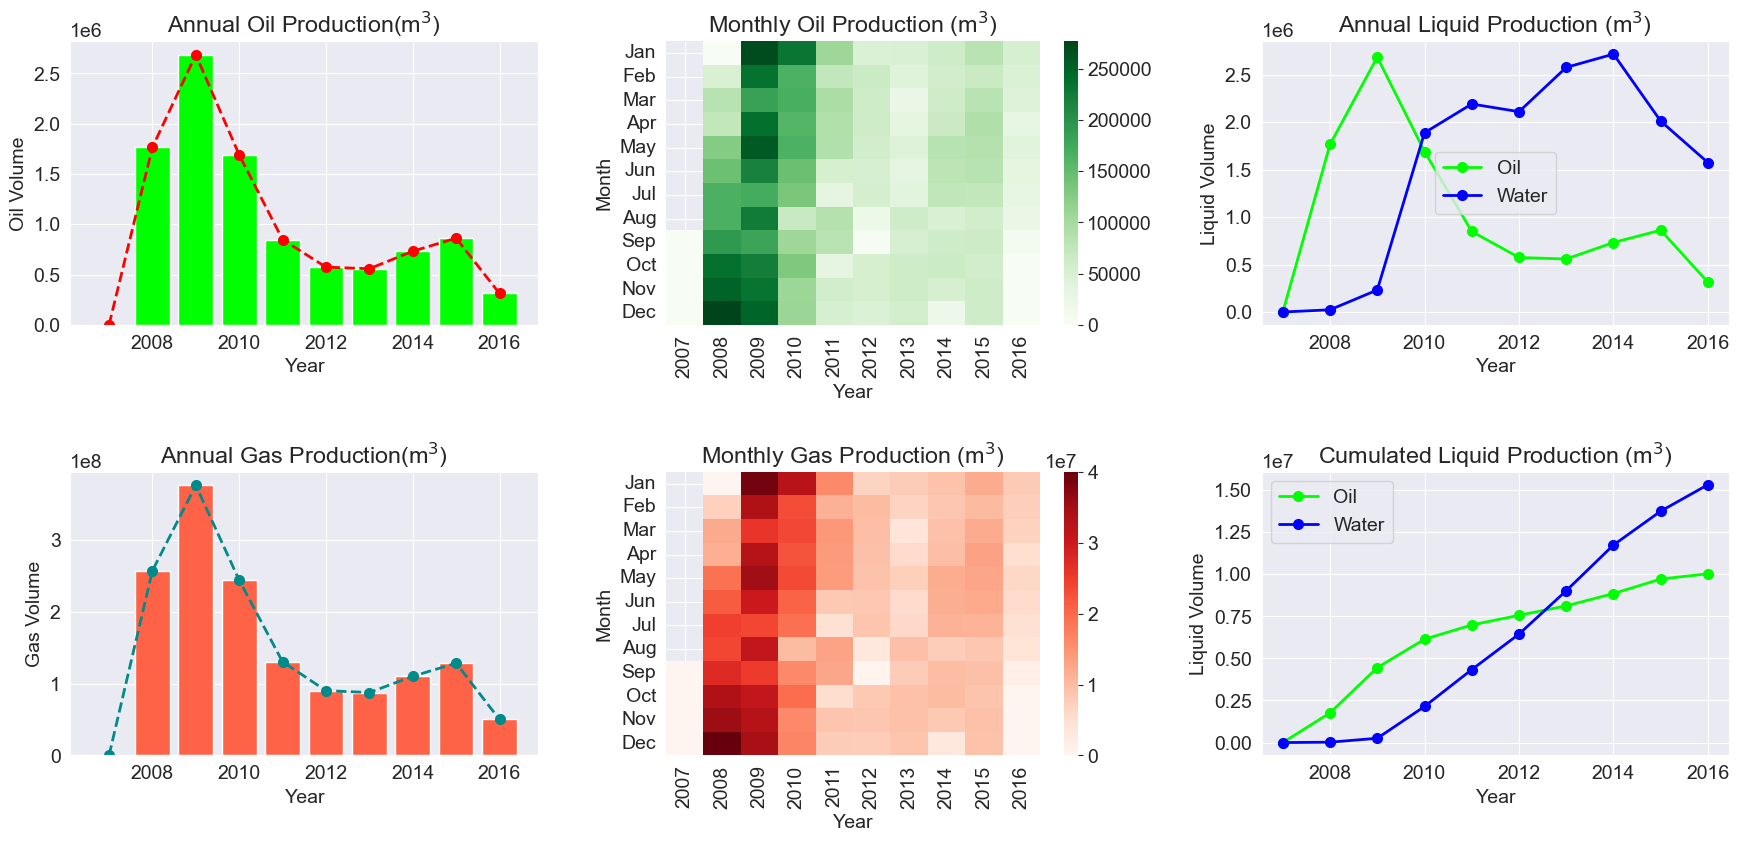

In [1008]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

axes[0, 0].bar(annual_production_df["YEAR"], annual_production_df["OIL"], color="lime")
axes[0, 0].plot(annual_production_df["YEAR"], annual_production_df["OIL"], "o--r", lw=2, ms=7)
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Oil Volume")
axes[0, 0].set_title("Annual Oil Production(m$^3$)")

sns.heatmap(monthly_oil_production_df, cmap="Greens", ax=axes[0, 1])
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Month")
axes[0, 1].set_title("Monthly Oil Production (m$^3$)")

axes[0, 2].plot(annual_production_df["YEAR"], annual_production_df["OIL"], color="lime", lw=2, marker="o", ms=7, label="Oil")
axes[0, 2].plot(annual_production_df["YEAR"], annual_production_df["WATER"], color="blue", lw=2, marker="o", ms=7, label="Water")
axes[0, 2].set_xlabel("Year")
axes[0, 2].set_ylabel("Liquid Volume")
axes[0, 2].legend(loc="center")
axes[0, 2].set_title("Annual Liquid Production (m$^3$)")

axes[1, 0].bar(annual_production_df["YEAR"], annual_production_df["GAS"], color="tomato")
axes[1, 0].plot(annual_production_df["YEAR"], annual_production_df["GAS"], color="darkcyan", ls="--", lw=2, marker="o", ms=7)
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Gas Volume")
axes[1, 0].set_title("Annual Gas Production(m$^3$)")

sns.heatmap(monthly_gas_production_df, cmap="Reds", ax=axes[1, 1])
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Month")
axes[1, 1].set_title("Monthly Gas Production (m$^3$)")

axes[1, 2].plot(annual_production_df["YEAR"], annual_production_df["CUM_OIL"], color="lime", lw=2, marker="o", ms=7, label="Oil")
axes[1, 2].plot(annual_production_df["YEAR"], annual_production_df["CUM_WATER"], color="blue", lw=2, marker="o", ms=7, label="Water")
axes[1, 2].set_xlabel("Year")
axes[1, 2].set_ylabel("Liquid Volume")
axes[1, 2].legend()
axes[1, 2].set_title("Cumulated Liquid Production (m$^3$)")

plt.tight_layout(pad=2)

## Wellbore Yield Comparison

### Questions

- Which wellbores produced the highest and lowest amounts of hydrocarbon?
- Which wellbore was the biggest water producer?

In [1009]:
production_wells_df, injection_wells_df = (generate_wellbores_dataframes(volve_df).get(key) for key in ("PRODUCTION", "INJECTION"))

In [1010]:
layout = go.Layout(
    title="<b>Fluid Production per Wellbore (m<sup>3</sup>)</b>",
    xaxis_title="Wellbore name",
    yaxis=dict(
        title="Liquid Volume",
        hoverformat=",.0f"
    ),
    yaxis2=dict(
        title="Gas Volume",
        overlaying="y",
        side="right",
        hoverformat=",.0f"
    ),
    legend=dict(orientation="h", x=0.35, y=-0.15),
    font_size=14,
    width=900,
    height=580
)

trace1 = go.Bar(
    x=production_wells_df["WELLBORE_NAME"],
    y=production_wells_df["OIL"],
    customdata=(production_wells_df["OIL"] / volumes.get("OIL")),
    hovertemplate="<br>".join(["<b>%{x}</b><br>", "<b>barrels:</b> %{customdata:,.0f}", "<b>cubic meters:</b> %{y}"]),
    marker=dict(color="#19CA9C", line=dict(color="whitesmoke", width=1.2)),
    offsetgroup=1,
    yaxis="y1",
    name="OIL"
)

trace2 = go.Bar(
    x=production_wells_df["WELLBORE_NAME"],
    y=production_wells_df["GAS"],
    customdata=(production_wells_df["GAS"] / volumes.get("GAS")),
    hovertemplate="<br>".join(["<b>%{x}</b><br>", "<b>SCF:</b> %{customdata:,.0f}", "<b>cubic meters:</b> %{y}"]),
    marker=dict(color="#EE553C", line=dict(color="whitesmoke", width=1.2)),
    offsetgroup=2,
    yaxis="y2",
    name="GAS"
)

trace3 = go.Bar(
    x=production_wells_df["WELLBORE_NAME"],
    y=production_wells_df["WATER"],
    customdata=(production_wells_df["WATER"] / volumes.get("WATER")),
    hovertemplate="<br>".join(["<b>%{x}</b><br>", "<b>barrels:</b> %{customdata:,.0f}", "<b>cubic meters:</b> %{y}"]),
    marker=dict(color="#636EFA", line=dict(color="whitesmoke", width=1.2)),
    offsetgroup=3,
    yaxis="y1",
    name="WATER"
)

go.Figure(data=[trace1, trace2, trace3], layout=layout)

### Answers

- The wellbore `15/9-F-12` produced the highest amount of hydrocarbon.
- The wellbore `15/9-F-5` produced the lowest amount of hydrocarbon. This is because its production life only began in **April 2016**, after being employed as an injection wellbore for waterflooding since **August 2016**.
- The wellbore `15/9-F-14` was the biggest water producer. The high amount of produced water from the wellbore may indicate a poor management of water production.

In [1011]:
layout = go.Layout(
    title="<b>Water Injection per Wellbore (m<sup>3</sup>)</b>",
    xaxis_title="Wellbore name",
    yaxis=dict(
        title="Water Volume",
        hoverformat=",.0f"
    ),
    font_size=14,
    width=900,
    height=580
)

trace = go.Bar(
    x=injection_wells_df["WELLBORE_NAME"],
    y=injection_wells_df["WI"],
    customdata=(injection_wells_df["WI"] / volumes.get("WATER")),
    hovertemplate="<br>".join(["<b>%{x}</b><br>", "<b>barrels:</b> %{customdata:,.0f}", "<b>cubic meters:</b> %{y}"]),
    hoverlabel=dict(bgcolor="aliceblue", font_color="#333"),
    marker=dict(color=injection_wells_df["WI"], colorscale="Blues", line=dict(color="gray", width=1.2)),
    name=""
)

go.Figure(data=[trace], layout=layout)

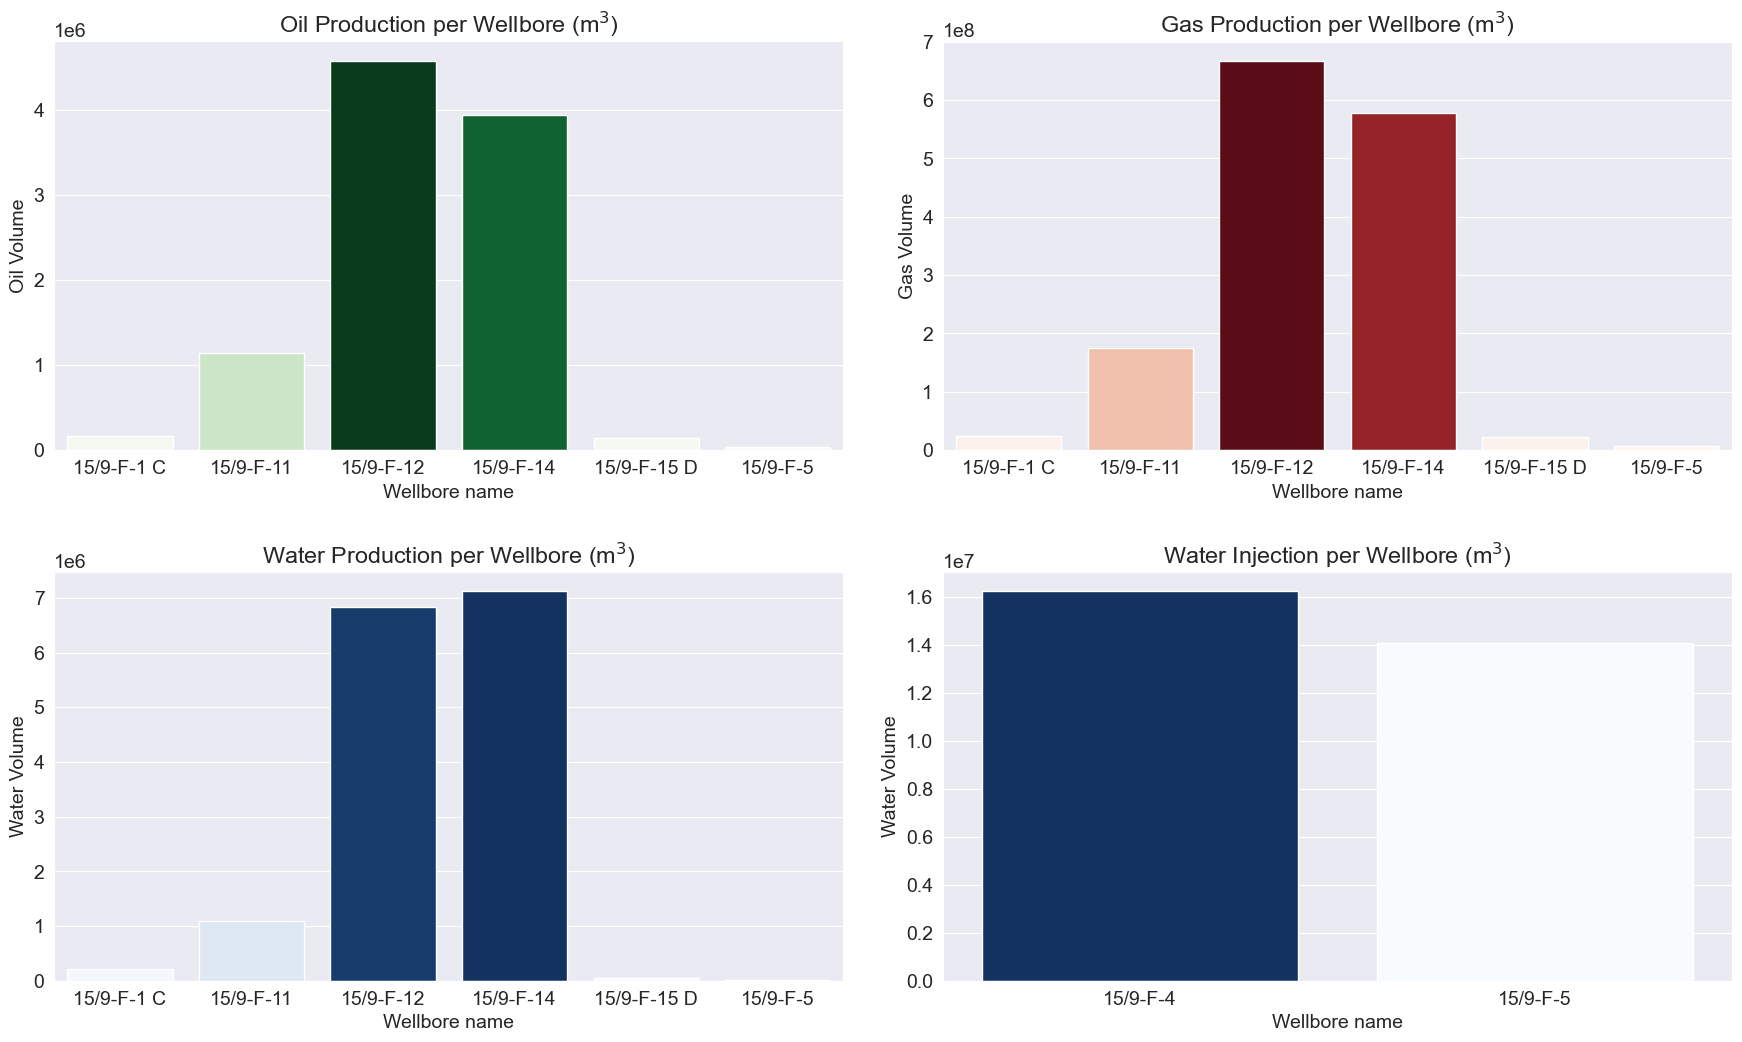

In [1012]:
fig, axes = plt.subplots(2, 2, figsize=(18, 11))

sns.barplot(x="WELLBORE_NAME", y="OIL", hue="OIL", palette="Greens", dodge=False, data=production_wells_df, ax=axes[0, 0]).legend_.remove()
axes[0, 0].set_xlabel("Wellbore name")
axes[0, 0].set_ylabel("Oil Volume")
axes[0, 0].set_title("Oil Production per Wellbore (m$^3$)")

sns.barplot(x="WELLBORE_NAME", y="GAS", hue="GAS", palette="Reds", dodge=False, data=production_wells_df, ax=axes[0, 1]).legend_.remove()
axes[0, 1].set_xlabel("Wellbore name")
axes[0, 1].set_ylabel("Gas Volume")
axes[0, 1].set_title("Gas Production per Wellbore (m$^3$)")

sns.barplot(x="WELLBORE_NAME", y="WATER", hue="WATER", palette="Blues", dodge=False, data=production_wells_df, ax=axes[1, 0]).legend_.remove()
axes[1, 0].set_xlabel("Wellbore name")
axes[1, 0].set_ylabel("Water Volume")
axes[1, 0].set_title("Water Production per Wellbore (m$^3$)")

sns.barplot(x="WELLBORE_NAME", y="WI", hue="WI", palette="Blues", dodge=False, data=injection_wells_df, ax=axes[1, 1]).legend_.remove()
axes[1, 1].set_xlabel("Wellbore name")
axes[1, 1].set_ylabel("Water Volume")
axes[1, 1].set_title("Water Injection per Wellbore (m$^3$)")

plt.tight_layout(pad=2)

## Wellbore Production Analysis

The individual analysis of each wellbore will help provide a more accurate picture of the events. As there are seven (07) wellbores in the dataset, analyzing them one after the other would be time-consuming. We will therefore proceed by creating functions to automate the process.

In [1013]:
# PRODUCTION WELLS

def analyze_production_wellbore(data: pd.DataFrame, well_name: str) -> go.Figure:
    fig = make_subplots(
        rows=2,
        cols=2,
        vertical_spacing=0.175,
        subplot_titles=(
            "<b>Annual Oil Production (m<sup>3</sup>)</b>", "<b>Monthly Oil Production (m<sup>3</sup>)</b>",
            "<b>Annual Gas Production (m<sup>3</sup>)</b>", "<b>Monthly Gas Production (m<sup>3</sup>)</b>"
        )
    )

    annual_df = annual_data(data, well_name)
    monthly_oil_df, monthly_gas_df = (generate_monthly_dataframes(data, well_name).get(key) for key in ("OIL", "GAS"))

    trace1 = go.Bar(
        x=annual_df["YEAR"],
        y=annual_df["OIL"],
        customdata=(annual_df["OIL"] / volumes.get("OIL")),
        hovertemplate="<br>".join(["<b>%{x}</b><br>", "<b>barrels:</b> %{customdata:,.0f}", "<b>cubic meters:</b> %{y:,.0f}"]),
        marker=dict(color="mediumspringgreen", line=dict(color="whitesmoke", width=1.2)),
        showlegend=False,
        name=""
    )

    trace2 = go.Heatmap(
        x=monthly_oil_df.columns,
        y=monthly_oil_df.index,
        z=monthly_oil_df.values,
        customdata=(monthly_oil_df.values / volumes.get("OIL")),
        hovertemplate="<br>".join(["<b>%{y} %{x}</b><br>", "<b>barrels:</b> %{customdata:,.0f}", "<b>cubic meters:</b> %{z:,.0f}"]),
        hoverlabel=dict(bgcolor="#F2FBF0", font_color="#333"),
        colorscale="Greens",
        showscale=False,
        name=""
    )

    trace3 = go.Bar(
        x=annual_df["YEAR"],
        y=annual_df["GAS"],
        customdata=(annual_df["GAS"] / volumes.get("GAS")),
        hovertemplate="<br>".join(["<b>%{x}</b><br>", "<b>SCF:</b> %{customdata:,.0f}", "<b>cubic meters:</b> %{y:,.0f}"]),
        marker=dict(color="crimson", line=dict(color="whitesmoke", width=1.2)),
        showlegend=False,
        name=""
    )
    trace4 = go.Heatmap(
        x=monthly_gas_df.columns,
        y=monthly_gas_df.index,
        z=monthly_gas_df.values,
        customdata=(monthly_gas_df.values / volumes.get("GAS")),
        hovertemplate="<br>".join(["<b>%{y} %{x}</b><br>", "<b>SCF:</b> %{customdata:,.0f}", "<b>cubic meters:</b> %{z:,.0f}"]),
        hoverlabel=dict(bgcolor="#FEF5F1", font_color="#333"),
        colorscale="Reds",
        showscale=False,
        name=""
    )

    data = [trace1, trace2, trace3, trace4]
    i = 0

    for row in range(1, 3):
        for col in range(1, 3):
            fig.add_trace(data[i], row=row, col=col)
            i += 1
            fig.update_xaxes(title="Year", tickmode="array", tickvals=annual_df["YEAR"], row=row, col=col)

    fig.update_yaxes(title=dict(text="Oil Volume", standoff=3), row=1, col=1)
    fig.update_yaxes(title=dict(text="Gas Volume", standoff=3), row=2, col=1)
    fig.update_yaxes(title=dict(text="Month", standoff=3), autorange="reversed", row=1, col=2)
    fig.update_yaxes(title=dict(text="Month", standoff=3), autorange="reversed", row=2, col=2)

    for trace in fig.layout.annotations:
        trace.font.size = 18

    fig.update_layout(
        title=dict(text=f"<b>Wellbore {well_name.upper()}</b>", font_size=20),
        height=1000,
        font_size=14,
        margin=dict(t=120)
    )

    return fig

In [1014]:
# INJECTION WELLS

def analyze_injection_wellbore(data: pd.DataFrame, well_name: str) -> go.Figure:
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=(
            "<b>Annual Water Injection (m<sup>3</sup>)</b>",
            "<b>Monthly Water Injection (m<sup>3</sup>)</b>"
        )
    )

    annual_df = annual_data(data, well_name)
    monthly_water_injection_df = monthly_data(data, well_name, parameter="WI")

    trace1 = go.Bar(
        x=annual_df["YEAR"],
        y=annual_df["WI"],
        customdata=(annual_df["WI"] / volumes.get("WATER")),
        hovertemplate="<br>".join(["<b>%{x}</b><br>", "<b>barrels:</b> %{customdata:,.0f}", "<b>cubic meters:</b> %{y:,.0f}"]),
        hoverlabel=dict(bgcolor="aliceblue", font_color="#333"),
        marker=dict(color="deepskyblue", line=dict(color="whitesmoke", width=1.2)),
        name=""
    )

    trace2 = go.Heatmap(
        x=monthly_water_injection_df.columns,
        y=monthly_water_injection_df.index,
        z=monthly_water_injection_df.values,
        customdata=(monthly_water_injection_df.values / volumes.get("WATER")),
        hovertemplate="<br>".join(["<b>%{y} %{x}</b><br>", "<b>barrels:</b> %{customdata:,.0f}", "<b>cubic meters:</b> %{z:,.0f}"]),
        hoverlabel=dict(bgcolor="aliceblue", font_color="#333"),
        colorscale="Blues",
        showscale=False,
        name=""
    )

    fig.add_trace(trace1, row=1, col=1)
    fig.add_trace(trace2, row=1, col=2)

    for col in range(1, 3):
        fig.update_xaxes(title="Year", tickmode="array", tickvals=annual_df["YEAR"], row=1, col=col)

    fig.update_yaxes(title=dict(text="Water Volume", standoff=3), col=1)
    fig.update_yaxes(title=dict(text="Month", standoff=3), autorange="reversed", col=2)
    for trace in fig.layout.annotations:
        trace.font.size = 18

    fig.update_layout(
        title=dict(text=f"<b>Wellbore {well_name.upper()}</b>", font_size=20),
        height=530,
        font_size=14,
        margin=dict(t=120)
    )

    return fig

In [1015]:
# HYBRID WELLS

def analyze_hybrid_wellbore(data: pd.DataFrame, well_name: str) -> go.Figure:
    fig = make_subplots(
        rows=2,
        cols=3,
        vertical_spacing=0.185,
        subplot_titles=(
            "<b>Annual Oil Production (m<sup>3</sup>)</b>", "<b>Annual Gas Production (m<sup>3</sup>)</b>",
            "<b>Annual Water Injection (m<sup>3</sup>)</b>", "<b>Monthly Oil Production (m<sup>3</sup>)</b>",
            "<b>Monthly Gas Production (m<sup>3</sup>)</b>", "<b>Monthly Water Injection (m<sup>3</sup>)</b>"
        )
    )

    annual_df = annual_data(data, well_name)
    monthly_oil_df, monthly_gas_df, monthly_wi_df = (generate_monthly_dataframes(data, well_name).get(key) for key in ("OIL", "GAS", "WI"))

    trace1 = go.Bar(
        x=annual_df["YEAR"],
        y=annual_df["OIL"],
        customdata=(annual_df["OIL"] / volumes.get("OIL")),
        hovertemplate="<br>".join(["<b>%{x}</b><br>", "<b>barrels:</b> %{customdata:,.0f}", "<b>cubic meters:</b> %{y:,.0f}"]),
        marker=dict(color="mediumspringgreen", line=dict(color="whitesmoke", width=1.2)),
        showlegend=False,
        name=""
    )

    trace2 = go.Bar(
        x=annual_df["YEAR"],
        y=annual_df["GAS"],
        customdata=(annual_df["GAS"] / volumes.get("GAS")),
        hovertemplate="<br>".join(["<b>%{x}</b><br>", "<b>SCF:</b> %{customdata:,.0f}", "<b>cubic meters:</b> %{y:,.0f}"]),
        marker=dict(color="crimson", line=dict(color="whitesmoke", width=1.2)),
        showlegend=False,
        name=""
    )

    trace3 = go.Bar(
        x=annual_df["YEAR"],
        y=annual_df["WI"],
        customdata=(annual_df["WI"] / volumes.get("WATER")),
        hovertemplate="<br>".join(["<b>%{x}</b><br>", "<b>barrels:</b> %{customdata:,.0f}", "<b>cubic meters:</b> %{y:,.0f}"]),
        marker=dict(color="deepskyblue", line=dict(color="whitesmoke", width=1.2)),
        showlegend=False,
        name=""
    )

    trace4 = go.Heatmap(
        x=monthly_oil_df.columns,
        y=monthly_oil_df.index,
        z=monthly_oil_df.values,
        customdata=(monthly_oil_df.values / volumes.get("OIL")),
        hovertemplate="<br>".join(["<b>%{y} %{x}</b><br>", "<b>barrels:</b> %{customdata:,.0f}", "<b>cubic meters:</b> %{z:,.0f}"]),
        hoverlabel=dict(bgcolor="#F2FBF0", font_color="#333"),
        colorscale="Greens",
        showscale=False,
        name=""
    )

    trace5 = go.Heatmap(
        x=monthly_gas_df.columns,
        y=monthly_gas_df.index,
        z=monthly_gas_df.values,
        customdata=(monthly_gas_df.values / volumes.get("GAS")),
            hovertemplate="<br>".join(["<b>%{y} %{x}</b><br>", "<b>SCF:</b> %{customdata:,.0f}", "<b>cubic meters:</b> %{z:,.0f}"]),
        hoverlabel=dict(bgcolor="#FEF5F1", font_color="#333"),
        colorscale="Reds",
        showscale=False,
        name=""
    )

    trace6 = go.Heatmap(
        x=monthly_wi_df.columns,
        y=monthly_wi_df.index,
        z=monthly_wi_df.values,
        customdata=(monthly_wi_df.values / volumes.get("WATER")),
        hovertemplate="<br>".join(["<b>%{y} %{x}</b><br>", "<b>barrels:</b> %{customdata:,.0f}", "<b>cubic meters:</b> %{z:,.0f}"]),
        hoverlabel=dict(bgcolor="aliceblue", font_color="#333"),
        colorscale="Blues",
        showscale=False,
        name=""
    )

    data = [trace1, trace2, trace3, trace4, trace5, trace6]
    i = 0

    for row in range(1, 3):
        for col in range(1, 4):
            fig.add_trace(data[i], row=row, col=col)
            i += 1
            fig.update_xaxes(title="Year", tickmode="array", tickvals=annual_df["YEAR"], row=row, col=col)

    fig.update_yaxes(title=dict(text="Oil Volume", standoff=3), row=1, col=1)
    fig.update_yaxes(title=dict(text="Gas Volume", standoff=3), row=1, col=2)
    fig.update_yaxes(title=dict(text="Water Volume", standoff=3), row=1, col=3)
    fig.update_yaxes(title=dict(text="Month", standoff=3), autorange="reversed", row=2, col=1)
    fig.update_yaxes(title=dict(text="Month", standoff=3), autorange="reversed", row=2, col=2)
    fig.update_yaxes(title=dict(text="Month", standoff=3), autorange="reversed", row=2, col=3)

    for trace in fig.layout.annotations:
        trace.font.size = 18

    fig.update_layout(
        title=dict(text=f"<b>Wellbore {well_name.upper()}</b>", font_size=20),
        height=810,
        font_size=14,
        margin=dict(t=120)
    )

    return fig

In [1016]:
def analyze_wellbore(data: pd.DataFrame, well_name: str) -> go.Figure:
    well_type = determine_well_type(data, well_name)

    if well_type == "PRODUCTION":
        return analyze_production_wellbore(data, well_name)
    elif well_type == "INJECTION":
        return analyze_injection_wellbore(data, well_name)
    else:
        return analyze_hybrid_wellbore(data, well_name)

In [1017]:
analyze_wellbore(volve_df, "15/9-F-12")

In [1018]:
analyze_wellbore(volve_df, "15/9-F-14")

In [1019]:
analyze_wellbore(volve_df, "15/9-F-11")

In [1020]:
analyze_wellbore(volve_df, "15/9-F-15 D")

In [1021]:
analyze_wellbore(volve_df, "15/9-F-1 C")

In [1022]:
analyze_wellbore(volve_df, "15/9-F-4")

In [1023]:
analyze_wellbore(volve_df, "15/9-F-5")

## Chronology of Events

### 2008
- **Feb:** Beginning of hydrocarbon production from the wellbore `15/9-F-12` <br><br>
- **Apr:** Beginning of secondary recovery via water injection from the wellbore `15/9-F-4` <br><br>
- **Jul:** The wellbore `15/9-F-14` started producing hydrocarbons <br><br>
- **Aug:** Introduction of the wellbore `15/9-F-5` to aid in water injection <br><br>

### 2012
- **Aug - Sep:** The field was temporarily shut down due to an anchor line repair. There is a noticeable decrease in hydrocarbon production and water injection for the wellbores `F12`, `F14`, `F4`, and `F5`. <br><br>

### 2013
- **Jul**: The wellbore `15/9-F-11` started producing hydrocarbons (*New wellbore*) <br><br>

### 2014
- **Jan:** The wellbore `15/9-F-15 D` started producing hydrocarbons (*New wellbore*) <br><br>
- **Apr:** The wellbore `15/9-F-1 C` started producing hydrocarbons (*New wellbore*) <br><br>
- **Dec:** Interruption of operations for the wellbores `15/9-F-12` and `15/9-F-15 D` (*Why?*) <br><br>

### 2015
- **Jan:** Production operations re-started for the wellbores `15/9-F-12` and `15/9-F-15 D` <br><br>

### 2016
- **Apr:** End of operations for the wellbore `15/9-F-1 C` <br><br>
- **Jul:** End of operations for the wellbores `15/9-F-14` and `15/9-F-15 D` <br><br>
- **Aug:** End of operations for the wellbores `15/9-F-12` and `15/9-F-5` <br><br>
- **Sep:** End of operations for the wellbores `15/9-F-4` and `15/9-F-11` (*Abandonment of the field*) <br><br>

## Machine Learning — Preprocessing

### Step 1: Define the target (Water Cut)
Water Cut is the percentage of water in the total liquid produced.

Water Cut = WATER / (OIL + WATER) * 100

### Step 2: Remove rows with no production
Some wells (like 15/9-F-4) are pure water injection wells — they never 
produce oil or water, so OIL + WATER = 0 for them. Water Cut has no 
meaning for these rows, so we remove them before calculating it.

In [1024]:
# Step 1 & 2: Define target and filter out non-production rows

# Remove rows where there is no liquid production at all
volve_df = volve_df[(volve_df["OIL"] + volve_df["WATER"]) > 0].copy()

# Now calculate Water Cut safely
volve_df["WATER_CUT"] = volve_df["WATER"] / (volve_df["OIL"] + volve_df["WATER"]) * 100

print(volve_df.shape)
volve_df[["WELLBORE_NAME", "YEAR", "MONTH", "OIL", "WATER", "WATER_CUT"]].head(10)

(297, 11)


,WELLBORE_NAME,YEAR,MONTH,OIL,WATER,WATER_CUT
10,15/9-F-12,2008,Feb,49091.06,412.61,0.833494
14,15/9-F-12,2008,Mar,83361.26,27.42,0.032882
18,15/9-F-12,2008,Apr,74532.45,482.05,0.642609
22,15/9-F-12,2008,May,125478.56,16280.12,11.484390
26,15/9-F-12,2008,Jun,143786.85,474.37,0.328827
30,15/9-F-12,2008,Jul,114994.61,290.02,0.251569
31,15/9-F-14,2008,Jul,51285.08,126.17,0.245413
34,15/9-F-12,2008,Aug,97822.46,354.18,0.360758
35,15/9-F-14,2008,Aug,67621.20,222.53,0.328004
38,15/9-F-12,2008,Sep,77666.95,188.39,0.241974


## Note on dataset size

After filtering to production-only rows, the monthly dataset contains 
297 rows — small for training a robust ML model, and below the 
minimum dataset size required for this project.

To address both issues, we incorporate the Daily Production Data sheet 
(15,634 rows), which also provides downhole pressure and temperature — 
physical signals not available in the monthly data and directly relevant 
to predicting water breakthrough.


## Adding Daily Production Data (Pressure & Temperature)

The monthly dataset alone is small (297 rows). We bring in the Daily 
Production Data sheet, which also includes downhole pressure and 
temperature — useful physical signals for predicting water cut.

We keep only production wells (WELL_TYPE == "OP"), since injection 
wells don't have these sensor readings.

In [1025]:
# Load the daily sheet
daily_df = pd.read_excel("Volve production data.xlsx", sheet_name="Daily Production Data")

# Keep production wells only
daily_df = daily_df[daily_df["WELL_TYPE"] == "OP"].copy()

print(daily_df.shape)
daily_df[["DATEPRD", "NPD_WELL_BORE_NAME", "AVG_DOWNHOLE_PRESSURE", 
          "AVG_DOWNHOLE_TEMPERATURE", "BORE_OIL_VOL", "BORE_WAT_VOL"]].head(10)

(9143, 24)


,DATEPRD,NPD_WELL_BORE_NAME,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,BORE_OIL_VOL,BORE_WAT_VOL
1,2014-04-08,15/9-F-1 C,NaN,NaN,0.0,0.0
2,2014-04-09,15/9-F-1 C,NaN,NaN,0.0,0.0
3,2014-04-10,15/9-F-1 C,NaN,NaN,0.0,0.0
4,2014-04-11,15/9-F-1 C,310.37614,96.87589,0.0,0.0
5,2014-04-12,15/9-F-1 C,303.50078,96.92339,0.0,0.0
6,2014-04-13,15/9-F-1 C,303.53481,96.95885,0.0,0.0
7,2014-04-14,15/9-F-1 C,303.78228,96.96873,0.0,0.0
8,2014-04-15,15/9-F-1 C,303.85821,97.02136,0.0,0.0
9,2014-04-16,15/9-F-1 C,303.79187,97.06569,0.0,0.0
10,2014-04-17,15/9-F-1 C,304.33518,96.91946,0.0,0.0


## Clean sensor errors in pressure/temperature

A value of exactly 0 for pressure or temperature while the well is 
producing oil is not physically realistic — it's a sensor reading 
error, not a real measurement. We convert these zeros to NaN so they 
don't distort later averages.

In [1026]:
import numpy as np

print("Zero pressure rows before:", (daily_df["AVG_DOWNHOLE_PRESSURE"] == 0).sum())

daily_df["AVG_DOWNHOLE_PRESSURE"] = daily_df["AVG_DOWNHOLE_PRESSURE"].replace(0, np.nan)
daily_df["AVG_DOWNHOLE_TEMPERATURE"] = daily_df["AVG_DOWNHOLE_TEMPERATURE"].replace(0, np.nan)

print("Zero pressure rows after:", (daily_df["AVG_DOWNHOLE_PRESSURE"] == 0).sum())
print("Missing pressure now:", daily_df["AVG_DOWNHOLE_PRESSURE"].isna().sum())

Zero pressure rows before: 2311
Zero pressure rows after: 0
Missing pressure now: 2476


## Aggregate daily data to monthly

We group the daily data by well and month, then calculate the average 
pressure and temperature for each well-month. This matches the level 
of detail in our monthly dataset so we can merge them together.

In [1027]:
# Extract year and month from the date column
daily_df["YEAR"] = daily_df["DATEPRD"].dt.year
daily_df["MONTH_NUM"] = daily_df["DATEPRD"].dt.month

# Group by well and month, average the pressure/temperature
daily_monthly = daily_df.groupby(
    ["NPD_WELL_BORE_NAME", "YEAR", "MONTH_NUM"], as_index=False
)[["AVG_DOWNHOLE_PRESSURE", "AVG_DOWNHOLE_TEMPERATURE"]].mean()

print(daily_monthly.shape)
daily_monthly.head(10)

(311, 5)


,NPD_WELL_BORE_NAME,YEAR,MONTH_NUM,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE
0,15/9-F-1 C,2014,4,281.283718,102.058556
1,15/9-F-1 C,2014,5,223.970505,107.815733
2,15/9-F-1 C,2014,6,217.458386,108.004911
3,15/9-F-1 C,2014,7,215.313723,108.151182
4,15/9-F-1 C,2014,8,230.621998,105.879476
5,15/9-F-1 C,2014,9,229.763020,107.569033
6,15/9-F-1 C,2014,10,220.303858,108.346780
7,15/9-F-1 C,2014,11,227.586997,107.280609
8,15/9-F-1 C,2014,12,289.154270,101.606167
9,15/9-F-1 C,2015,1,250.128915,105.737095


## Check for missing values after aggregation

Some well-months might still have missing pressure/temperature if 
every daily reading that month was a sensor error (0). We check how 
many rows are affected before merging.

In [1028]:
print("Missing pressure:", daily_monthly["AVG_DOWNHOLE_PRESSURE"].isna().sum())
print("Missing temperature:", daily_monthly["AVG_DOWNHOLE_TEMPERATURE"].isna().sum())
print("Total rows:", daily_monthly.shape[0])

# Show which well-months are affected
daily_monthly[daily_monthly["AVG_DOWNHOLE_PRESSURE"].isna()]

Missing pressure: 81
Missing temperature: 81
Total rows: 311


,NPD_WELL_BORE_NAME,YEAR,MONTH_NUM,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE
97,15/9-F-12,2010,11,NaN,NaN
98,15/9-F-12,2010,12,NaN,NaN
99,15/9-F-12,2011,1,NaN,NaN
100,15/9-F-12,2011,2,NaN,NaN
101,15/9-F-12,2011,3,NaN,NaN
...,...,...,...,...,...
306,15/9-F-5,2016,5,NaN,NaN
307,15/9-F-5,2016,6,NaN,NaN
308,15/9-F-5,2016,7,NaN,NaN
309,15/9-F-5,2016,8,NaN,NaN


## Investigate the pattern of missing values

Before deciding how to handle the 81 missing rows, we check whether 
they're concentrated in specific wells or time periods, or spread out 
randomly.

In [1029]:
missing_rows = daily_monthly[daily_monthly["AVG_DOWNHOLE_PRESSURE"].isna()]

print("Missing rows by well:")
print(missing_rows["NPD_WELL_BORE_NAME"].value_counts())
print()
print("Missing rows by year:")
print(missing_rows["YEAR"].value_counts().sort_index())

Missing rows by well:
NPD_WELL_BORE_NAME
15/9-F-12    71
15/9-F-5      6
15/9-F-14     4
Name: count, dtype: int64

Missing rows by year:
YEAR
2008     3
2010     2
2011    12
2012    12
2013    12
2014    12
2015    12
2016    16
Name: count, dtype: int64


## Decision: drop rows with missing pressure data

88% of the missing values come from a single well (15/9-F-12), spread 
fairly evenly across years — this looks like a long-term sensor gap, 
not a short outage we could reasonably estimate. We drop these rows 
rather than impute them, to avoid introducing artificial bias for 
this well.

In [1030]:
daily_monthly = daily_monthly.dropna(subset=["AVG_DOWNHOLE_PRESSURE", "AVG_DOWNHOLE_TEMPERATURE"])
print(daily_monthly.shape)

(230, 5)


## Merge pressure/temperature data with the monthly dataset

Before merging, we need both tables to use the same month format. 
volve_df has month names ("Jan", "Feb"...), while daily_monthly has 
month numbers (1, 2...). We convert volve_df's month to numbers, then 
merge on well name + year + month.

In [1031]:
import calendar

# Map month names back to numbers in volve_df
month_to_num = {name: num for num, name in enumerate(calendar.month_abbr) if num != 0}
volve_df["MONTH_NUM"] = volve_df["MONTH"].map(month_to_num)

# Merge on well name + year + month
volve_df = volve_df.merge(
    daily_monthly,
    left_on=["WELLBORE_NAME", "YEAR", "MONTH_NUM"],
    right_on=["NPD_WELL_BORE_NAME", "YEAR", "MONTH_NUM"],
    how="inner"
)

print(volve_df.shape)
volve_df[["WELLBORE_NAME", "YEAR", "MONTH", "WATER_CUT", 
          "AVG_DOWNHOLE_PRESSURE", "AVG_DOWNHOLE_TEMPERATURE"]].head(10)

(223, 15)


,WELLBORE_NAME,YEAR,MONTH,WATER_CUT,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE
0,15/9-F-12,2008,Feb,0.833494,293.861069,105.757083
1,15/9-F-12,2008,Mar,0.032882,278.622659,105.805915
2,15/9-F-12,2008,Apr,0.642609,264.300441,105.791779
3,15/9-F-12,2008,May,11.484390,263.449732,102.725694
4,15/9-F-12,2008,Jun,0.328827,258.793692,104.953576
5,15/9-F-12,2008,Jul,0.251569,264.462809,106.147244
6,15/9-F-14,2008,Jul,0.245413,255.998373,100.452383
7,15/9-F-12,2008,Aug,0.360758,261.117901,106.086336
8,15/9-F-14,2008,Aug,0.328004,249.943215,102.857258
9,15/9-F-12,2008,Sep,0.241974,255.337394,105.752127


## Clean up extra columns from the merge

The merge added a duplicate well-name column and a helper month-number 
column we no longer need. We drop them to keep the dataset tidy.

In [1032]:
volve_df = volve_df.drop(columns=["NPD_WELL_BORE_NAME", "MONTH_NUM"])

print(volve_df.shape)
volve_df.columns.tolist()

(223, 13)


['WELLBORE_NAME',
 'NPDCODE',
 'YEAR',
 'MONTH',
 'ON_STREAM',
 'OIL',
 'GAS',
 'WATER',
 'GI',
 'WI',
 'WATER_CUT',
 'AVG_DOWNHOLE_PRESSURE',
 'AVG_DOWNHOLE_TEMPERATURE']

## Sort data chronologically

Before creating lag features, we sort the data by well and by date 
(year, then month). This ensures that when we look at "the previous 
month" for a well, we're getting the correct one.

In [1033]:
# Map month names to numbers again for correct sorting
month_to_num = {name: num for num, name in enumerate(calendar.month_abbr) if num != 0}
volve_df["MONTH_NUM"] = volve_df["MONTH"].map(month_to_num)

volve_df = volve_df.sort_values(["WELLBORE_NAME", "YEAR", "MONTH_NUM"]).reset_index(drop=True)

volve_df[["WELLBORE_NAME", "YEAR", "MONTH"]].head(15)

,WELLBORE_NAME,YEAR,MONTH
0,15/9-F-1 C,2014,May
1,15/9-F-1 C,2014,Jun
2,15/9-F-1 C,2014,Jul
3,15/9-F-1 C,2014,Aug
4,15/9-F-1 C,2014,Sep
5,15/9-F-1 C,2014,Oct
6,15/9-F-1 C,2014,Nov
7,15/9-F-1 C,2014,Dec
8,15/9-F-1 C,2015,Jan
9,15/9-F-1 C,2015,Feb


## Feature engineering

We create three new features based on reservoir engineering logic:
- GOR (Gas-Oil Ratio): large changes can signal water breakthrough
- CUM_OIL: cumulative oil production, a proxy for reservoir depletion
- WELL_AGE_MONTHS: how many months the well has been producing

In [1034]:
# Gas-Oil Ratio
volve_df["GOR"] = np.where(volve_df["OIL"] == 0, 0, volve_df["GAS"] / volve_df["OIL"])

# Cumulative oil production per well
volve_df["CUM_OIL"] = volve_df.groupby("WELLBORE_NAME")["OIL"].cumsum()

# Well age in months (1, 2, 3... per well)
volve_df["WELL_AGE_MONTHS"] = volve_df.groupby("WELLBORE_NAME").cumcount() + 1

volve_df[["WELLBORE_NAME", "YEAR", "MONTH", "GOR", "CUM_OIL", "WELL_AGE_MONTHS"]].head(10)

,WELLBORE_NAME,YEAR,MONTH,GOR,CUM_OIL,WELL_AGE_MONTHS
0,15/9-F-1 C,2014,May,140.399834,24901.95,1
1,15/9-F-1 C,2014,Jun,147.145326,44519.71,2
2,15/9-F-1 C,2014,Jul,149.106023,59605.39,3
3,15/9-F-1 C,2014,Aug,150.376777,66575.82,4
4,15/9-F-1 C,2014,Sep,154.235784,75744.25,5
5,15/9-F-1 C,2014,Oct,154.420651,85212.31,6
6,15/9-F-1 C,2014,Nov,155.609083,91922.64,7
7,15/9-F-1 C,2014,Dec,214.956189,92042.93,8
8,15/9-F-1 C,2015,Jan,147.573001,102918.46,9
9,15/9-F-1 C,2015,Feb,150.152052,112505.10,10


## Lag features (previous month's values)

We add the previous month's water cut and oil production as features, 
calculated per well using .shift(1). This gives the model temporal 
context without leaking future information.

In [1035]:
volve_df["WATER_CUT_LAG1"] = volve_df.groupby("WELLBORE_NAME")["WATER_CUT"].shift(1)
volve_df["OIL_LAG1"] = volve_df.groupby("WELLBORE_NAME")["OIL"].shift(1)

volve_df[["WELLBORE_NAME", "YEAR", "MONTH", "WATER_CUT", "WATER_CUT_LAG1"]].head(10)

,WELLBORE_NAME,YEAR,MONTH,WATER_CUT,WATER_CUT_LAG1
0,15/9-F-1 C,2014,May,3.050290,NaN
1,15/9-F-1 C,2014,Jun,9.538214,3.050290
2,15/9-F-1 C,2014,Jul,29.273697,9.538214
3,15/9-F-1 C,2014,Aug,39.388514,29.273697
4,15/9-F-1 C,2014,Sep,47.567085,39.388514
5,15/9-F-1 C,2014,Oct,52.260912,47.567085
6,15/9-F-1 C,2014,Nov,51.878545,52.260912
7,15/9-F-1 C,2014,Dec,60.395746,51.878545
8,15/9-F-1 C,2015,Jan,38.647594,60.395746
9,15/9-F-1 C,2015,Feb,52.848640,38.647594


## Drop rows with missing lag values

Each well's first month has no "previous month" to look back at, so 
WATER_CUT_LAG1 and OIL_LAG1 are NaN for those rows. We drop them before 
training, since models can't handle missing values.

In [1036]:
print("Rows before:", volve_df.shape[0])

volve_df = volve_df.dropna(subset=["WATER_CUT_LAG1", "OIL_LAG1"]).reset_index(drop=True)

print("Rows after:", volve_df.shape[0])

Rows before: 223
Rows after: 218


## Encode wellbore name (One-Hot Encoding)

WELLBORE_NAME is text, but models need numbers. We convert it into 
separate 0/1 columns — one per well — so the model can learn 
well-specific patterns instead of treating all wells as identical.

In [1037]:
volve_df = pd.get_dummies(volve_df, columns=["WELLBORE_NAME"], prefix="WELL")

print(volve_df.shape)
volve_df.columns.tolist()

(218, 23)


['NPDCODE',
 'YEAR',
 'MONTH',
 'ON_STREAM',
 'OIL',
 'GAS',
 'WATER',
 'GI',
 'WI',
 'WATER_CUT',
 'AVG_DOWNHOLE_PRESSURE',
 'AVG_DOWNHOLE_TEMPERATURE',
 'MONTH_NUM',
 'GOR',
 'CUM_OIL',
 'WELL_AGE_MONTHS',
 'WATER_CUT_LAG1',
 'OIL_LAG1',
 'WELL_15/9-F-1 C',
 'WELL_15/9-F-11',
 'WELL_15/9-F-12',
 'WELL_15/9-F-14',
 'WELL_15/9-F-15 D']

In [1038]:
print(volve_df.filter(like="F-5").columns.tolist())

[]


In [1039]:
well_cols = [col for col in volve_df.columns if col.startswith("WELL_")]
volve_df[well_cols] = volve_df[well_cols].astype(int)

volve_df[well_cols].head()

,WELL_AGE_MONTHS,WELL_15/9-F-1 C,WELL_15/9-F-11,WELL_15/9-F-12,WELL_15/9-F-14,WELL_15/9-F-15 D
0,2,1,0,0,0,0
1,3,1,0,0,0,0
2,4,1,0,0,0,0
3,5,1,0,0,0,0
4,6,1,0,0,0,0


In [1040]:
volve_df.head()

,NPDCODE,YEAR,MONTH,ON_STREAM,OIL,GAS,WATER,GI,WI,WATER_CUT,...,GOR,CUM_OIL,WELL_AGE_MONTHS,WATER_CUT_LAG1,OIL_LAG1,WELL_15/9-F-1 C,WELL_15/9-F-11,WELL_15/9-F-12,WELL_15/9-F-14,WELL_15/9-F-15 D
0,7405,2014,Jun,705.91666,19617.76,2886661.69,2068.48,0.0,0.0,9.538214,...,147.145326,44519.71,2,3.050290,24901.95,1,0,0,0,0
1,7405,2014,Jul,742.41666,15085.68,2249365.75,6243.98,0.0,0.0,29.273697,...,149.106023,59605.39,3,9.538214,19617.76,1,0,0,0,0
2,7405,2014,Aug,432.99166,6970.43,1048190.80,4529.75,0.0,0.0,39.388514,...,150.376777,66575.82,4,29.273697,15085.68,1,0,0,0,0
3,7405,2014,Sep,630.30000,9168.43,1414099.99,8317.59,0.0,0.0,47.567085,...,154.235784,75744.25,5,39.388514,6970.43,1,0,0,0,0
4,7405,2014,Oct,745.00000,9468.06,1462063.99,10364.87,0.0,0.0,52.260912,...,154.420651,85212.31,6,47.567085,9168.43,1,0,0,0,0


## Note: wellbore 15/9-F-5 is no longer in the dataset

15/9-F-5 had very few records to begin with (5 rows in the original 
monthly data) and is also a hybrid well (used for both production and 
injection). After merging with pressure/temperature data and creating 
lag features — both of which require consecutive, complete records — 
none of its rows survived. This is a known limitation of the dataset, 
not a bug: we report it rather than disguise it.

# Create a single time index (so we can sort/split globally across all wells)
volve_df["TIME_IDX"] = volve_df["YEAR"] * 12 + volve_df["MONTH_NUM"]

# Use the 80th percentile of the timeline as the cutoff
cutoff = volve_df["TIME_IDX"].quantile(0.8)

train_df = volve_df[volve_df["TIME_IDX"] <= cutoff]
test_df = volve_df[volve_df["TIME_IDX"] > cutoff]

print("Train rows:", train_df.shape[0])
print("Test rows:", test_df.shape[0])
print("Train years:", train_df["YEAR"].min(), "-", train_df["YEAR"].max())
print("Test years:", test_df["YEAR"].min(), "-", test_df["YEAR"].max())

In [1041]:
# Make sure YEAR and MONTH_NUM are actual numbers, not category type
volve_df["YEAR"] = volve_df["YEAR"].astype(int)
volve_df["MONTH_NUM"] = volve_df["MONTH_NUM"].astype(int)

# Create a single time index (so we can sort/split globally across all wells)
volve_df["TIME_IDX"] = volve_df["YEAR"] * 12 + volve_df["MONTH_NUM"]

# Use the 80th percentile of the timeline as the cutoff
cutoff = volve_df["TIME_IDX"].quantile(0.8)

train_df = volve_df[volve_df["TIME_IDX"] <= cutoff]
test_df = volve_df[volve_df["TIME_IDX"] > cutoff]

print("Train rows:", train_df.shape[0])
print("Test rows:", test_df.shape[0])
print("Train years:", train_df["YEAR"].min(), "-", train_df["YEAR"].max())
print("Test years:", test_df["YEAR"].min(), "-", test_df["YEAR"].max())

Train rows: 175
Test rows: 43
Train years: 2008 - 2015
Test years: 2015 - 2016


## Define final features and target

We explicitly list which columns go into the model (features) and 
which are excluded. WATER and WATER_CUT are excluded because the 
target is calculated directly from them — including them would leak 
the answer into the model.

In [1042]:
well_cols = [col for col in volve_df.columns if col.startswith("WELL_")]

features = ["ON_STREAM", "OIL", "GAS", "GI", "WI",
            "AVG_DOWNHOLE_PRESSURE", "AVG_DOWNHOLE_TEMPERATURE",
            "GOR", "CUM_OIL", "WELL_AGE_MONTHS",
            "WATER_CUT_LAG1", "OIL_LAG1"] + well_cols

target = "WATER_CUT"

# Remove the duplicate while keeping the original order
features = list(dict.fromkeys(features))
print("Features now:", len(features))
print(features)

print("Number of features:", len(features))
print(features)

Features now: 17
['ON_STREAM', 'OIL', 'GAS', 'GI', 'WI', 'AVG_DOWNHOLE_PRESSURE', 'AVG_DOWNHOLE_TEMPERATURE', 'GOR', 'CUM_OIL', 'WELL_AGE_MONTHS', 'WATER_CUT_LAG1', 'OIL_LAG1', 'WELL_15/9-F-1 C', 'WELL_15/9-F-11', 'WELL_15/9-F-12', 'WELL_15/9-F-14', 'WELL_15/9-F-15 D']
Number of features: 17
['ON_STREAM', 'OIL', 'GAS', 'GI', 'WI', 'AVG_DOWNHOLE_PRESSURE', 'AVG_DOWNHOLE_TEMPERATURE', 'GOR', 'CUM_OIL', 'WELL_AGE_MONTHS', 'WATER_CUT_LAG1', 'OIL_LAG1', 'WELL_15/9-F-1 C', 'WELL_15/9-F-11', 'WELL_15/9-F-12', 'WELL_15/9-F-14', 'WELL_15/9-F-15 D']


## Apply features to train/test sets

We now extract only the selected features (X) and the target (y) from 
the train and test sets.

In [1043]:
X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train.head()

X_train: (175, 17)
X_test: (43, 17)


,ON_STREAM,OIL,GAS,GI,WI,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,GOR,CUM_OIL,WELL_AGE_MONTHS,WATER_CUT_LAG1,OIL_LAG1,WELL_15/9-F-1 C,WELL_15/9-F-11,WELL_15/9-F-12,WELL_15/9-F-14,WELL_15/9-F-15 D
0,705.91666,19617.76,2886661.69,0.0,0.0,217.458386,108.004911,147.145326,44519.71,2,3.050290,24901.95,1,0,0,0,0
1,742.41666,15085.68,2249365.75,0.0,0.0,215.313723,108.151182,149.106023,59605.39,3,9.538214,19617.76,1,0,0,0,0
2,432.99166,6970.43,1048190.80,0.0,0.0,230.621998,105.879476,150.376777,66575.82,4,29.273697,15085.68,1,0,0,0,0
3,630.30000,9168.43,1414099.99,0.0,0.0,229.763020,107.569033,154.235784,75744.25,5,39.388514,6970.43,1,0,0,0,0
4,745.00000,9468.06,1462063.99,0.0,0.0,220.303858,108.346780,154.420651,85212.31,6,47.567085,9168.43,1,0,0,0,0


In [1044]:
X_train.isna().sum()

ON_STREAM                   0
OIL                         0
GAS                         0
GI                          0
WI                          0
AVG_DOWNHOLE_PRESSURE       0
AVG_DOWNHOLE_TEMPERATURE    0
GOR                         0
CUM_OIL                     0
WELL_AGE_MONTHS             0
WATER_CUT_LAG1              0
OIL_LAG1                    0
WELL_15/9-F-1 C             0
WELL_15/9-F-11              0
WELL_15/9-F-12              0
WELL_15/9-F-14              0
WELL_15/9-F-15 D            0
dtype: int64

## Model 1: Linear Regression (baseline)

A simple model to set a baseline. Linear Regression is sensitive to 
feature scale, so we standardize the features first using StandardScaler.

In [1045]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Scale features (needed for Linear Regression only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_lr = lr_model.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression — RMSE: {rmse_lr:.2f}, MAE: {mae_lr:.2f}, R2: {r2_lr:.3f}")

Linear Regression — RMSE: 6.15, MAE: 5.10, R2: 0.881


## Model 2: Random Forest + GridSearchCV

We tune Random Forest using GridSearchCV with TimeSeriesSplit (instead 
of regular cross-validation), to respect the time order of our data. 
We limit tree depth and leaf size to prevent overfitting, since our 
dataset is small.

In [1046]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 8],
    "min_samples_leaf": [1, 3, 5]
}

tscv = TimeSeriesSplit(n_splits=4)

rf_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error"
)
rf_search.fit(X_train, y_train)

best_rf_model = rf_search.best_estimator_
print("Best parameters:", rf_search.best_params_)

y_pred_rf = best_rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest — RMSE: {rmse_rf:.2f}, MAE: {mae_rf:.2f}, R2: {r2_rf:.3f}")

Best parameters: {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 200}
Random Forest — RMSE: 6.24, MAE: 4.34, R2: 0.877


## Model 3: Gradient Boosting + GridSearchCV

Gradient Boosting builds trees sequentially, each one correcting the 
previous tree's errors. We tune learning_rate and depth carefully, 
since this model is more prone to overfitting on small datasets than 
Random Forest.

In [1047]:
from sklearn.ensemble import GradientBoostingRegressor

gb_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 3, 5],
    "learning_rate": [0.01, 0.05, 0.1]
}

gb_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gb_param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error"
)
gb_search.fit(X_train, y_train)

best_gb_model = gb_search.best_estimator_
print("Best parameters:", gb_search.best_params_)

y_pred_gb = best_gb_model.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print(f"Gradient Boosting — RMSE: {rmse_gb:.2f}, MAE: {mae_gb:.2f}, R2: {r2_gb:.3f}")

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Gradient Boosting — RMSE: 7.98, MAE: 5.79, R2: 0.799


## Compare all three models and select the best

We summarize the three models in a table and a chart, then select the 
final model to use for the rest of the analysis.

,RMSE,MAE,R2
Linear Regression,6.152,5.101,0.881
Random Forest,6.242,4.342,0.877
Gradient Boosting,7.980,5.793,0.799


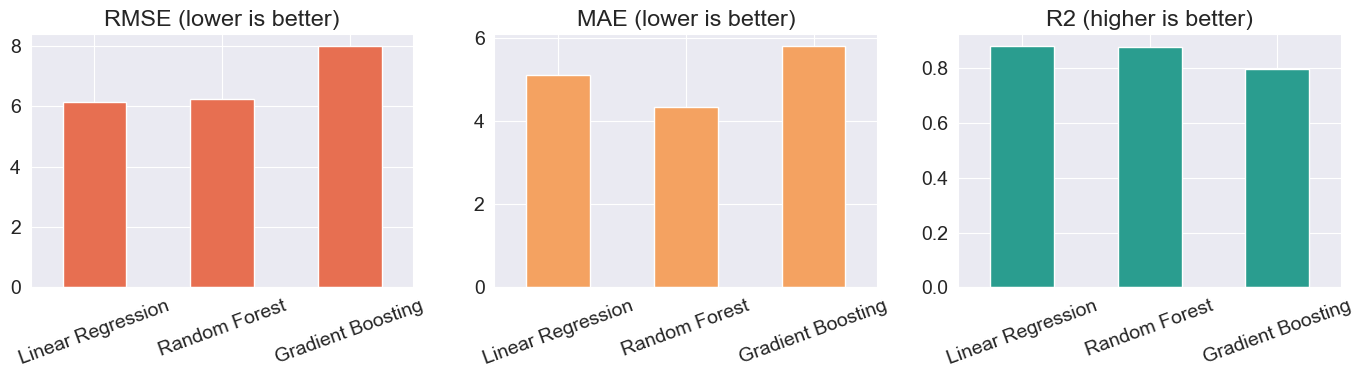

In [1048]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "RMSE": [rmse_lr, rmse_rf, rmse_gb],
    "MAE": [mae_lr, mae_rf, mae_gb],
    "R2": [r2_lr, r2_rf, r2_gb]
}, index=["Linear Regression", "Random Forest", "Gradient Boosting"])

display(results.round(3))

# Bar chart comparison
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
results["RMSE"].plot(kind="bar", ax=ax[0], title="RMSE (lower is better)", color="#e76f51")
results["MAE"].plot(kind="bar", ax=ax[1], title="MAE (lower is better)", color="#f4a261")
results["R2"].plot(kind="bar", ax=ax[2], title="R2 (higher is better)", color="#2a9d8f")
for a in ax:
    a.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

### Final model selection: Random Forest

While Linear Regression has a slightly lower RMSE, Random Forest has 
the lowest MAE (more accurate on average) and provides feature 
importance — useful for interpreting which factors drive water cut. 
The performance gap between the two is small, which suggests the 
simpler model is genuinely competitive on this dataset size, not that 
Random Forest is overfitting.

In [1049]:
final_model = best_rf_model
final_model_name = "Random Forest"
final_model_name 

'Random Forest'

## Feature importance

We examine which features the final model (Random Forest) relied on 
most, to connect the technical result back to a physical interpretation.

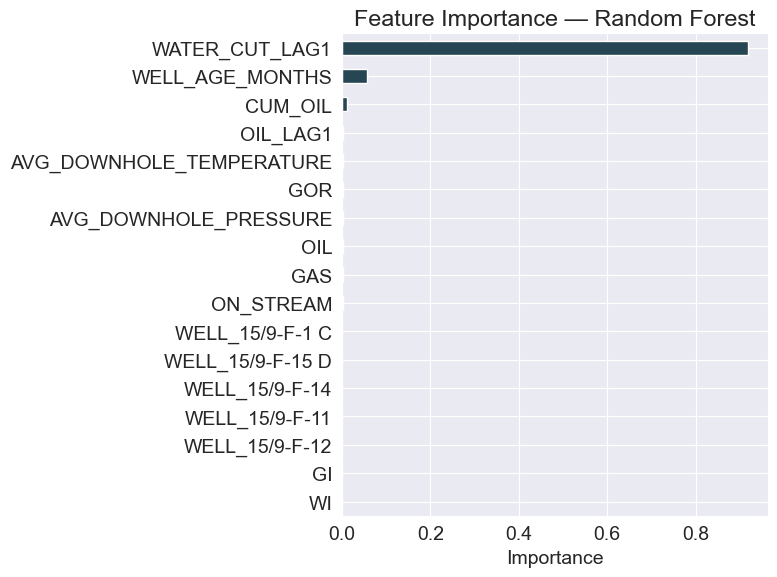

WATER_CUT_LAG1              0.918153
WELL_AGE_MONTHS             0.056946
CUM_OIL                     0.010885
OIL_LAG1                    0.002642
AVG_DOWNHOLE_TEMPERATURE    0.002320
GOR                         0.001988
AVG_DOWNHOLE_PRESSURE       0.001888
OIL                         0.001708
GAS                         0.001583
ON_STREAM                   0.001389
WELL_15/9-F-1 C             0.000177
WELL_15/9-F-15 D            0.000126
WELL_15/9-F-14              0.000078
WELL_15/9-F-11              0.000069
WELL_15/9-F-12              0.000048
GI                          0.000000
WI                          0.000000
dtype: float64


In [1050]:
importances = pd.Series(
    final_model.feature_importances_, index=features
).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.plot(kind="barh", color="#264653")
plt.gca().invert_yaxis()
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(importances)

In [1051]:
import joblib

joblib.dump(best_rf_model, "water_cut_model.pkl")
joblib.dump(scaler, "water_cut_scaler.pkl")
joblib.dump({
    "features": features,
    "well_columns": well_cols,
    "model_name": "Random Forest"
}, "water_cut_metadata.pkl")

print("Saved: water_cut_model.pkl, water_cut_scaler.pkl, water_cut_metadata.pkl")

Saved: water_cut_model.pkl, water_cut_scaler.pkl, water_cut_metadata.pkl


## Model Pipeline

We wrap the scaler and the best model into a single sklearn Pipeline.
This ensures that any new input automatically goes through the same
preprocessing steps before prediction — making the model safer and
easier to deploy.

In [1052]:
from sklearn.pipeline import Pipeline

# Build the pipeline: scaler + best Random Forest parameters
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=1,
        random_state=42
    ))
])

# Train the pipeline on the training data
pipeline.fit(X_train, y_train)

# Predict using the pipeline
y_pred_pipeline = pipeline.predict(X_test)

rmse_pipeline = np.sqrt(mean_squared_error(y_test, y_pred_pipeline))
mae_pipeline = mean_absolute_error(y_test, y_pred_pipeline)
r2_pipeline = r2_score(y_test, y_pred_pipeline)

print(f"Pipeline (RF) — RMSE: {rmse_pipeline:.2f}, MAE: {mae_pipeline:.2f}, R2: {r2_pipeline:.3f}")

Pipeline (RF) — RMSE: 6.24, MAE: 4.34, R2: 0.877


In [1053]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Pipeline Linear Regression
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', lr_model)
])
pipeline_lr.fit(X_train, y_train)

# Pipeline Gradient Boosting
pipeline_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('model', best_gb_model)
])
pipeline_gb.fit(X_train, y_train)

# save
joblib.dump(pipeline,    "water_cut_model.pkl")
joblib.dump(pipeline_lr, "water_cut_model_lr.pkl")
joblib.dump(pipeline_gb, "water_cut_model_gb.pkl")

joblib.dump({
    "features": features,
    "well_columns": well_cols,
    "model_name": "Random Forest Pipeline"
}, "water_cut_metadata.pkl")

print("Saved: water_cut_model.pkl (RF)")
print("Saved: water_cut_model_lr.pkl (LR)")
print("Saved: water_cut_model_gb.pkl (GB)")

Saved: water_cut_model.pkl (RF)
Saved: water_cut_model_lr.pkl (LR)
Saved: water_cut_model_gb.pkl (GB)
